# PEAD Project - Data Collection & Initial EDA
**Post-Earnings Announcement Drift: Multimodal ML Framework for S&P 500 Stocks**

## Pipeline Execution

In [1]:
# Run the full pipeline
from pead_all_pipeline import run_pipeline

# For all S&P 500 stocks:
modeling, daily = run_pipeline()

------------------------------------------------------------
Running pipeline for: ALL STOCKS
------------------------------------------------------------

- Loading data from S3 -
Earnings loaded: (24294, 12) | Symbols: 503
Transcripts loaded: (23313, 13) | Symbols: 500
OHLCV loaded: (4385666, 7) | Symbols: 503

- EPS features -
EPS features added for 503 symbols

- Sector & industry info -
  Sector info: 50/503 symbols
  Sector info: 100/503 symbols
  Sector info: 150/503 symbols
  Sector info: 200/503 symbols
  Sector info: 250/503 symbols
  Sector info: 300/503 symbols
  Sector info: 350/503 symbols
  Sector info: 400/503 symbols
  Sector info: 450/503 symbols
  Sector info: 500/503 symbols
  Sector info: 503/503 symbols
Sector info saved: (503, 3) | Nulls: 2

- Processing 503 symbols in 11 batches -

- Batch 1/11 (50 symbols) -
  TA indicators: 50/50 symbols
  Event windows: 50/50 symbols | 2416 events

Total: 2416 events | 8 skipped | shape: (50736, 25)
Pivoted: 2416 events × 254

In [2]:
# import libraries
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

pl.Config.set_fmt_str_lengths(50)


polars.config.Config

### Dataset Overview

In [3]:
# Dataset overview
print(f"Final modeling table: {modeling.shape[0]} events * {modeling.shape[1]} columns")
print(f"Symbols covered: {modeling['symbol'].n_unique()}")
print(f"Date range: {modeling['earnings_date'].min()} to {modeling['earnings_date'].max()}")
print(f"Total nulls: {modeling.null_count().sum_horizontal()[0]}")

# Events per symbol
event_counts = modeling.group_by("symbol").len().sort("len")
print(f"\nEvents per symbol:")
print(f"  Min: {event_counts['len'].min()}")
print(f"  Median: {event_counts['len'].median()}")
print(f"  Max: {event_counts['len'].max()}")

# Stocks with fewer than 10 events
low = event_counts.filter(pl.col("len") < 10)
if low.shape[0] > 0:
    print(f"\n {low.shape[0]} stocks with < 10 events (may be insufficient for modeling):")
    print(low.head(10))

# column breakdown
pivoted_cols = [c for c in modeling.columns if re.search(r"_t[+-]?\d+$", c)]
event_cols = [c for c in modeling.columns if c not in pivoted_cols]
print(f"\nColumn breakdown:")
print(f"  Pivoted (time-series) features: {len(pivoted_cols)}")
print(f"  Event-level features:           {len(event_cols)}")

Final modeling table: 24132 events * 274 columns
Symbols covered: 503
Date range: 2014-01-07 to 2026-05-14
Total nulls: 2143

Events per symbol:
  Min: 2
  Median: 50.0
  Max: 50

 4 stocks with < 10 events (may be insufficient for modeling):
shape: (4, 2)
┌────────┬─────┐
│ symbol ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ Q      ┆ 2   │
│ SNDK   ┆ 6   │
│ SOLV   ┆ 9   │
│ GEV    ┆ 9   │
└────────┴─────┘

Column breakdown:
  Pivoted (time-series) features: 252
  Event-level features:           22


### Scale Validation
Verify that every earnings event produced exactly 12 daily rows (t-10 through t+1).


In [4]:
# Scale validation
from pead_all_pipeline import feature_window, data_window
expected_rows = data_window[1] - data_window[0] + 1  

rows_per_event = daily.group_by("symbol", "earnings_date").len()
bad = rows_per_event.filter(pl.col("len") != expected_rows)

if bad.shape[0] > 0:
    print(f"{bad.shape[0]} events without exactly {expected_rows} rows:")
    print(bad.head(10))
else:
    print(f"All events have exactly {expected_rows} rows (t{feature_window[0]} through t+{feature_window[1]})")

print(f"\nDaily table: {daily.shape}")
print(f"Modeling table: {modeling.shape}")

All events have exactly 21 rows (t-10 through t+1)

Daily table: (506772, 25)
Modeling table: (24132, 274)


## Descriptive Statistics

### OHLCV & Technical Indicators at t0


In [5]:
# Descriptive stats for key features at t0
t0_cols = sorted([c for c in modeling.columns if c.endswith("_t0")])
print(f"Features at t0: {len(t0_cols)} columns\n")

# Price & volume
price_vol = [c for c in t0_cols if any(x in c for x in ["close", "high", "low", "open", "volume","obv"])]
print("--- Price & Volume ---")
print(modeling.select(price_vol).describe())

# Momentum & trend indicators
momentum = [c for c in t0_cols if any(x in c for x in ["rsi", "macd", "sma", "bb", "roc", "adx", "vwap"])]
print("\n--- Momentum & Trend ---")
print(modeling.select(momentum).describe())

# Volatility & derived
volatility = [c for c in t0_cols if any(x in c for x in ["atr", "daily_return", "intraday", "volume_change"])]
print("\n--- Volatility & Derived ---")
print(modeling.select(volatility).describe())

Features at t0: 21 columns

--- Price & Volume ---
shape: (9, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ close_t0   ┆ high_t0    ┆ low_t0    ┆ obv_t0    ┆ open_t0   ┆ volume_ch ┆ volume_t0 │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ange_t0   ┆ ---       │
│ str        ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆ ---       ┆ f64       │
│            ┆            ┆            ┆           ┆           ┆           ┆ f64       ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 24132.0    ┆ 24132.0    ┆ 24132.0   ┆ 24132.0   ┆ 24132.0   ┆ 24132.0   ┆ 24132.0   │
│ null_count ┆ 0.0        ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 121.068757 ┆ 123.485205 ┆ 118.55397 ┆ 0.930297  ┆ 121.01141 ┆ NaN       ┆ 1.1308e7  │
│            ┆            

### Earnings Fundamentals


In [6]:
print(modeling.select(
    "reportedEPS", "estimatedEPS", "surprise", "surprisePercentage",
    "eps_growth", "surprise_trend", "consecutive_beats"
).describe())

shape: (9, 8)
┌────────────┬────────────┬────────────┬──────────┬────────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ reportedEP ┆ estimatedE ┆ surprise ┆ surprisePe ┆ eps_growt ┆ surprise_ ┆ consecuti │
│ ---        ┆ S          ┆ PS         ┆ ---      ┆ rcentage   ┆ h         ┆ trend     ┆ ve_beats  │
│ str        ┆ ---        ┆ ---        ┆ f64      ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│            ┆ f64        ┆ f64        ┆          ┆ f64        ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪══════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 24132.0    ┆ 24067.0    ┆ 24132.0  ┆ 24041.0    ┆ 23663.0   ┆ 23663.0   ┆ 24132.0   │
│ null_count ┆ 0.0        ┆ 65.0       ┆ 0.0      ┆ 91.0       ┆ 469.0     ┆ 469.0     ┆ 0.0       │
│ mean       ┆ 1.595692   ┆ 1.500469   ┆ 0.097224 ┆ 11.609128  ┆ NaN       ┆ 0.005894  ┆ 4.458105  │
│ std        ┆ 4.076404   ┆ 3.865689   ┆ 0.599445 ┆ 283.666914 ┆ NaN       ┆ 

## Missing Value Analysis


In [7]:
# Missing values audit
total_cells = modeling.shape[0] * modeling.shape[1]
total_nulls = modeling.null_count().sum_horizontal()[0]
print(f"Total cells: {total_cells:,}")
print(f"Total nulls: {total_nulls:,} ({100 * total_nulls / total_cells:.2f}%)")

# Per-column breakdown (only columns with nulls)
cols_with_nulls = []
for c in modeling.columns:
    n = modeling[c].null_count()
    if n > 0:
        cols_with_nulls.append({
            "column": c,
            "nulls": n,
            "pct": round(100 * n / modeling.shape[0], 2)
        })

if cols_with_nulls:
    print("\nColumns with missing values:")
    print(pl.DataFrame(cols_with_nulls).sort("nulls", descending=True))
else:
    print("\nNo missing values found in any column")


Total cells: 6,612,168
Total nulls: 2,143 (0.03%)

Columns with missing values:
shape: (9, 3)
┌────────────────────┬───────┬──────┐
│ column             ┆ nulls ┆ pct  │
│ ---                ┆ ---   ┆ ---  │
│ str                ┆ i64   ┆ f64  │
╞════════════════════╪═══════╪══════╡
│ transcript         ┆ 947   ┆ 3.92 │
│ eps_growth         ┆ 469   ┆ 1.94 │
│ surprise_trend     ┆ 469   ┆ 1.94 │
│ surprisePercentage ┆ 91    ┆ 0.38 │
│ estimatedEPS       ┆ 65    ┆ 0.27 │
│ sector             ┆ 50    ┆ 0.21 │
│ industry           ┆ 50    ┆ 0.21 │
│ daily_return_t-10  ┆ 1     ┆ 0.0  │
│ volume_change_t-10 ┆ 1     ┆ 0.0  │
└────────────────────┴───────┴──────┘


In [8]:
# Event-level column types
print("Event-level columns:")
print("-" * 60)
for col in event_cols:
    null_pct = round(100 * modeling[col].null_count() / modeling.shape[0], 1)
    print(f"  {col:30s}  {str(modeling[col].dtype):15s}  nulls: {null_pct}%")

Event-level columns:
------------------------------------------------------------
  symbol                          String           nulls: 0.0%
  earnings_date                   Date             nulls: 0.0%
  fiscalDateEnding                Date             nulls: 0.0%
  reportedDate                    Date             nulls: 0.0%
  reportedEPS                     Float64          nulls: 0.0%
  estimatedEPS                    Float64          nulls: 0.3%
  surprise                        Float64          nulls: 0.0%
  surprisePercentage              Float64          nulls: 0.4%
  reportTime                      String           nulls: 0.0%
  fiscal_month                    Int8             nulls: 0.0%
  fiscal_year                     Int32            nulls: 0.0%
  av_quarter                      String           nulls: 0.0%
  time_from                       String           nulls: 0.0%
  eps_growth                      Float64          nulls: 1.9%
  surprise_trend                  Fl

In [9]:
# Duplicate event check
dupe_count = modeling.select("symbol", "earnings_date").is_duplicated().sum()
print(f"Duplicate events (same symbol + earnings_date): {dupe_count}")

if dupe_count > 0:
    dupes = modeling.filter(
        pl.struct("symbol", "earnings_date").is_duplicated()
    ).select("symbol", "earnings_date").unique()
    print("Duplicate event details:")
    print(dupes)
else:
    print("No duplicate events — each (symbol, earnings_date) pair is unique")

Duplicate events (same symbol + earnings_date): 0
No duplicate events — each (symbol, earnings_date) pair is unique


## Outlier Detection (IQR Method)

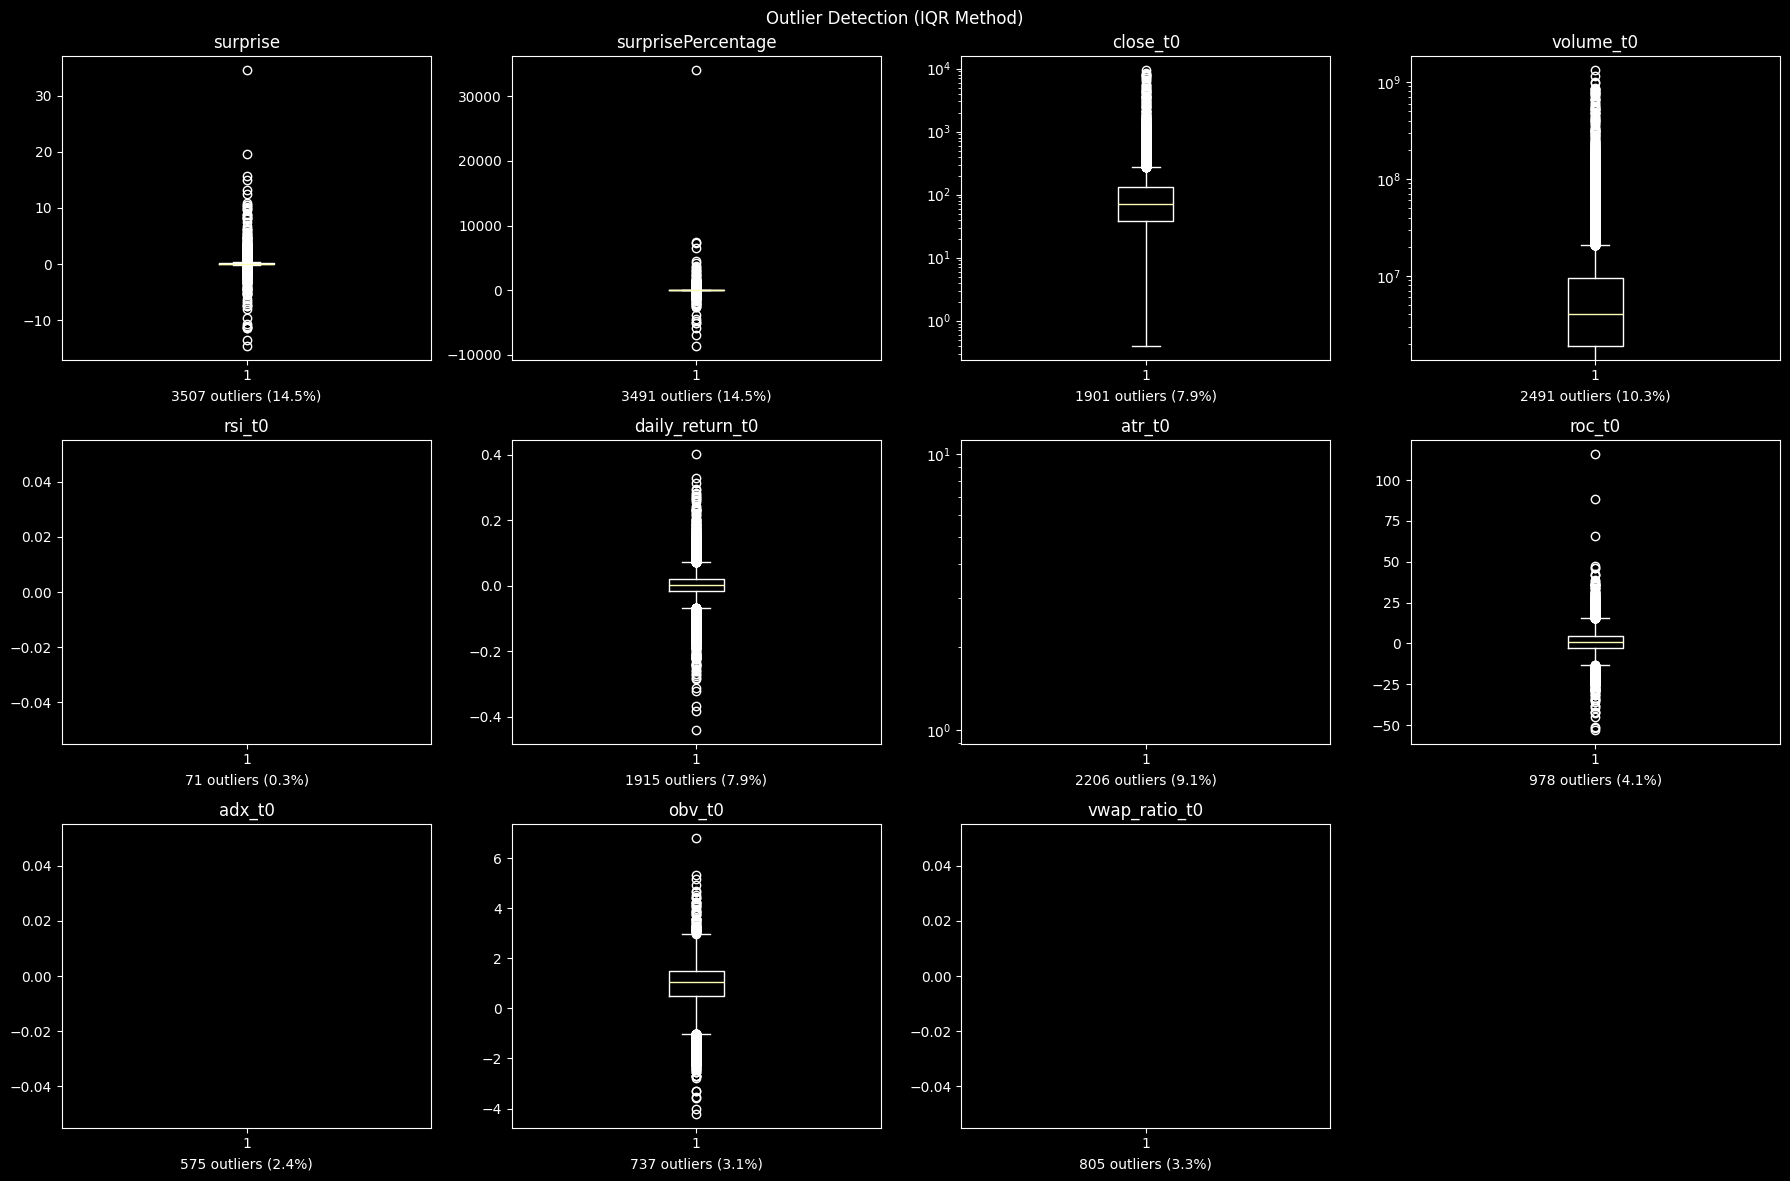

In [11]:
# Box plots with IQR-based outlier counts
check_cols = ["surprise", "surprisePercentage", "close_t0", "volume_t0",
              "rsi_t0", "daily_return_t0", "atr_t0",
              "roc_t0", "adx_t0", "obv_t0", "vwap_ratio_t0"]
check_cols = [c for c in check_cols if c in modeling.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    vals = modeling[col].drop_nulls().to_list()
    axes[i].boxplot(vals)
    if col in ["volume_t0", "atr_t0", "close_t0"]:
        axes[i].set_yscale("log")
    axes[i].set_title(col)

    q1, q3 = modeling[col].quantile(0.25), modeling[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = modeling.filter(
        (pl.col(col) < q1 - 1.5 * iqr) | (pl.col(col) > q3 + 1.5 * iqr)
    ).shape[0]
    axes[i].set_xlabel(f"{n_outliers} outliers ({100*n_outliers/modeling.shape[0]:.1f}%)")

for j in range(len(check_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection (IQR Method)")
plt.tight_layout()
plt.show()


In [12]:
# Flag inf values for preprocessing attention
inf_cols = []
for c in check_cols:
    n_inf = modeling.select(pl.col(c).is_infinite().sum())[0, 0]
    if n_inf > 0:
        inf_cols.append({"column": c, "inf_count": n_inf})

if inf_cols:
    print("\nColumns with inf values:")
    print(pl.DataFrame(inf_cols))
else:
    print("\nNo inf values in checked columns")


No inf values in checked columns


## Correlation & Relationship Analysis

### Correlation Heatmap at t0

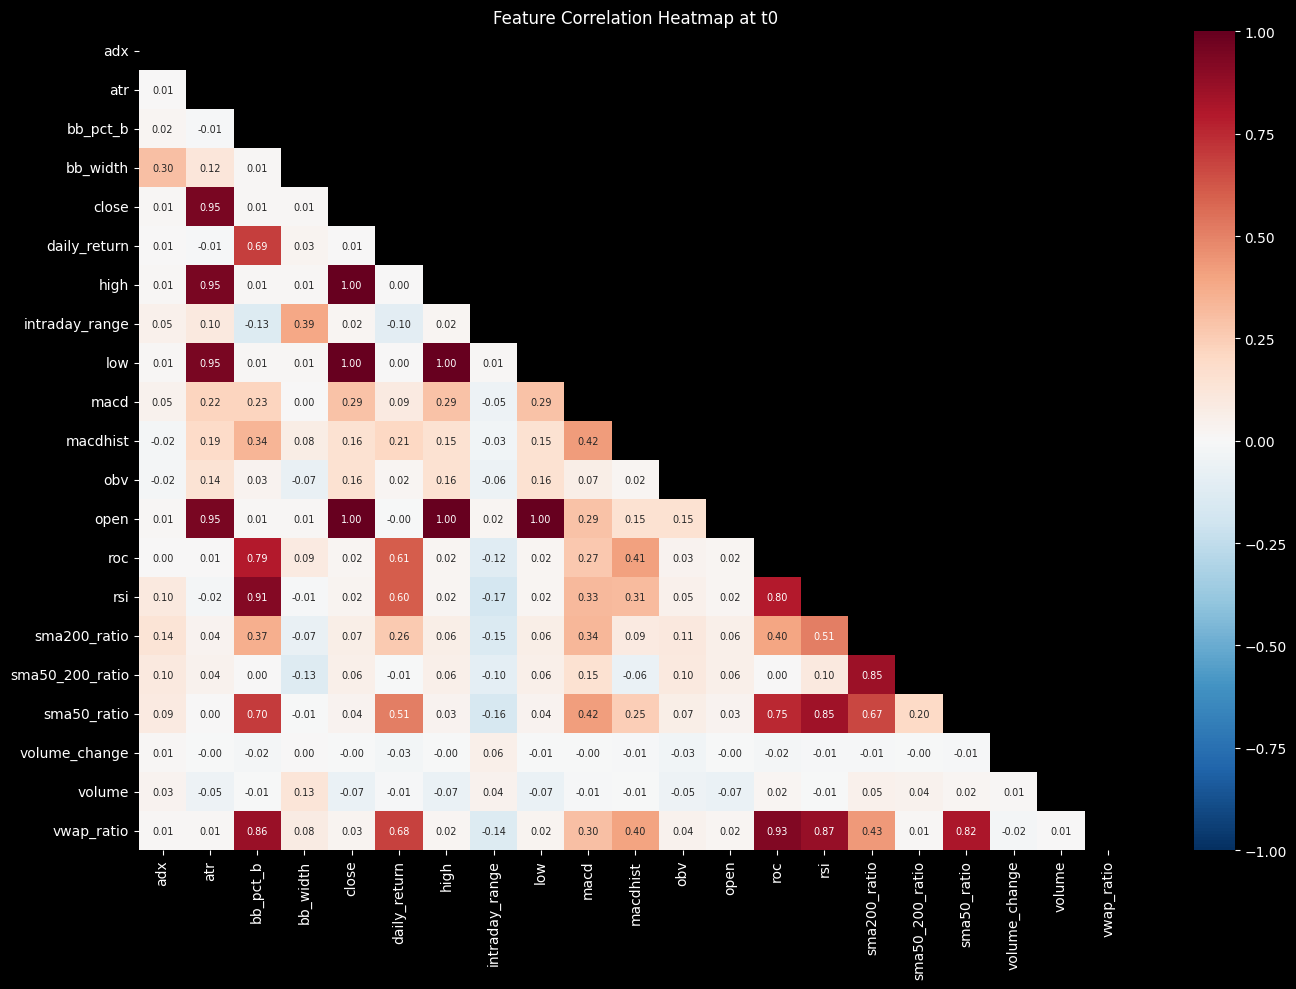


Highly correlated pairs (|r| > 0.90):
  atr_t0               ↔ close_t0              r = +0.951
  atr_t0               ↔ high_t0               r = +0.952
  atr_t0               ↔ low_t0                r = +0.950
  atr_t0               ↔ open_t0               r = +0.951
  bb_pct_b_t0          ↔ rsi_t0                r = +0.914
  close_t0             ↔ high_t0               r = +1.000
  close_t0             ↔ low_t0                r = +1.000
  close_t0             ↔ open_t0               r = +1.000
  high_t0              ↔ low_t0                r = +1.000
  high_t0              ↔ open_t0               r = +1.000
  low_t0               ↔ open_t0               r = +1.000
  roc_t0               ↔ vwap_ratio_t0         r = +0.927


In [13]:
# Correlation heatmap at t0
t0_cols = sorted([c for c in modeling.columns if c.endswith("_t0")])
t0_data = modeling.select(t0_cols).to_pandas()

fig, ax = plt.subplots(figsize=(14, 10))
corr = t0_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, vmin=-1, vmax=1, annot_kws={"size": 7},
            xticklabels=[c.replace("_t0", "") for c in t0_cols],
            yticklabels=[c.replace("_t0", "") for c in t0_cols])
ax.set_title("Feature Correlation Heatmap at t0")
plt.tight_layout()
plt.show()

# Highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.90):")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            print(f"  {corr.columns[i]:20s} ↔ {corr.columns[j]:20s}  r = {r:+.3f}")

## Class Distribution Analysis

Overall class distribution:
shape: (2, 2)
┌──────┬───────┐
│ beat ┆ len   │
│ ---  ┆ ---   │
│ i8   ┆ u32   │
╞══════╪═══════╡
│ 0    ┆ 6439  │
│ 1    ┆ 17693 │
└──────┴───────┘

Overall beat rate: 73.3%


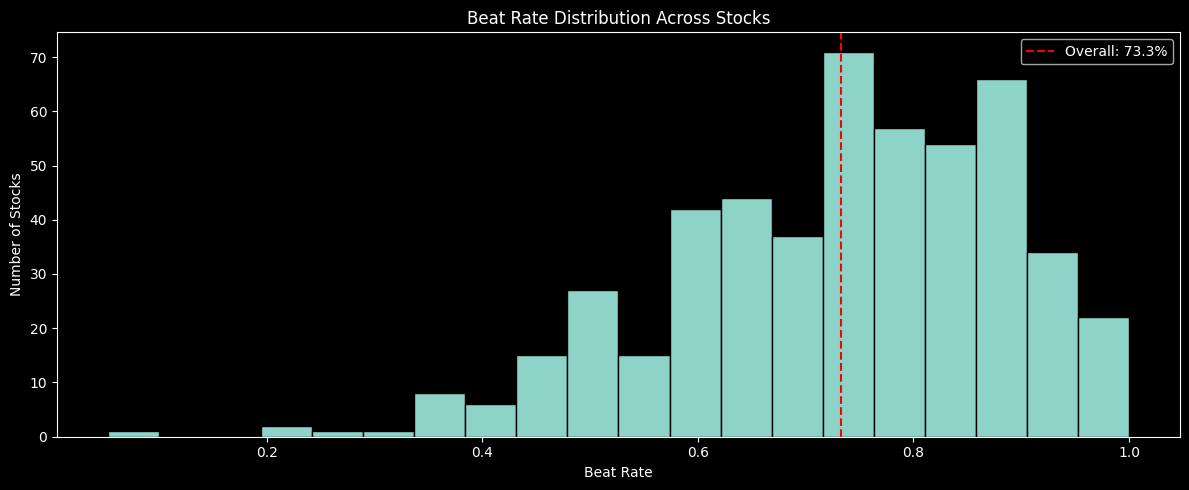

In [14]:
# Class balance — using beat column from pipeline
beat_dist = modeling.group_by("beat").len().sort("beat")
print("Overall class distribution:")
print(beat_dist)

beat_rate = modeling["beat"].mean()
print(f"\nOverall beat rate: {beat_rate:.1%}")

# Beat rate by symbol (check for per-stock imbalance)
per_stock = modeling.group_by("symbol").agg([
    pl.col("beat").mean().alias("beat_rate"),
    pl.len().alias("events"),
]).sort("beat_rate")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(per_stock["beat_rate"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=beat_rate, color="red", linestyle="--", label=f"Overall: {beat_rate:.1%}")
ax.set_title("Beat Rate Distribution Across Stocks")
ax.set_xlabel("Beat Rate")
ax.set_ylabel("Number of Stocks")
ax.legend()
plt.tight_layout()
plt.show()


Target direction distribution (what the model predicts):
shape: (2, 2)
┌──────────────────┬───────┐
│ target_direction ┆ len   │
│ ---              ┆ ---   │
│ i8               ┆ u32   │
╞══════════════════╪═══════╡
│ 0                ┆ 10536 │
│ 1                ┆ 13596 │
└──────────────────┴───────┘
Positive drift rate: 56.3%


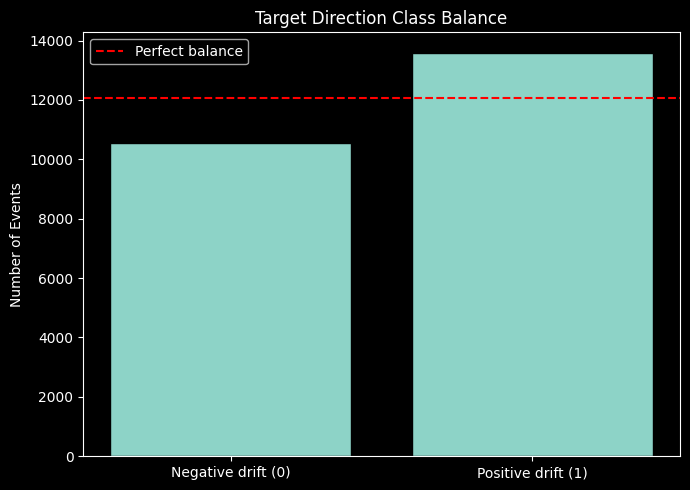

In [15]:
# Target direction balance
target_dist = modeling.group_by("target_direction").len().sort("target_direction")
print("\nTarget direction distribution (what the model predicts):")
print(target_dist)
target_rate = modeling["target_direction"].drop_nulls().mean()
print(f"Positive drift rate: {target_rate:.1%}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Negative drift (0)", "Positive drift (1)"],
       target_dist["len"].to_list(), edgecolor="black")
ax.set_title("Target Direction Class Balance")
ax.set_ylabel("Number of Events")
ax.axhline(y=modeling.shape[0]/2, color="red", linestyle="--", label="Perfect balance")
ax.legend()
plt.tight_layout()
plt.show()


Target return descriptive stats:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ target_return │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 24132.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 0.007498      │
│ std        ┆ 0.056238      │
│ min        ┆ -0.670921     │
│ 25%        ┆ -0.021657     │
│ 50%        ┆ 0.006797      │
│ 75%        ┆ 0.035594      │
│ max        ┆ 0.750633      │
└────────────┴───────────────┘


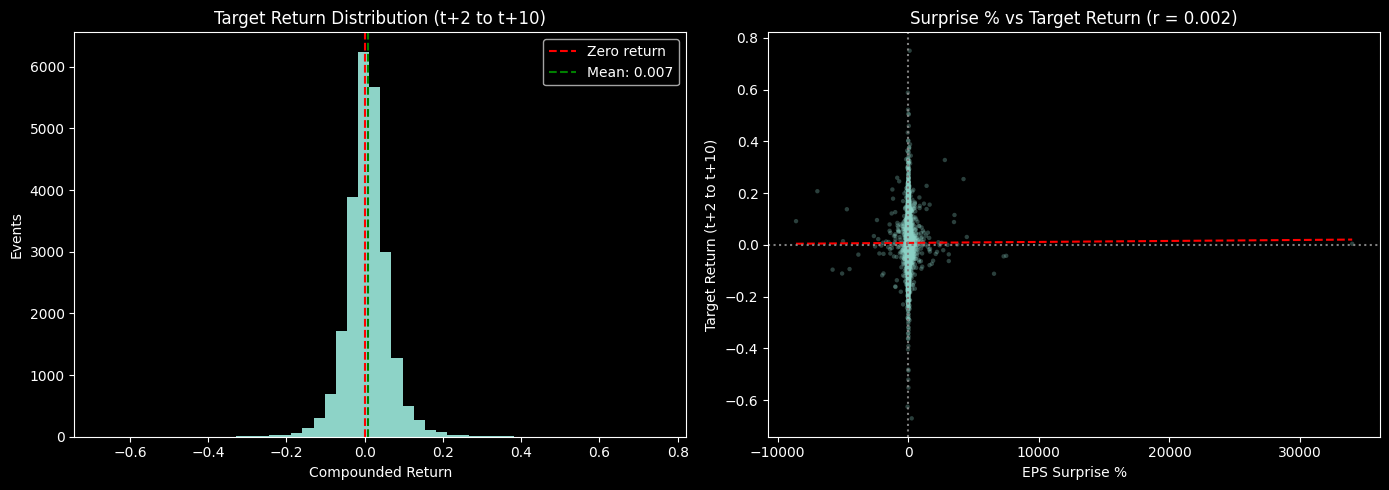

In [16]:
# Target return distribution
target_data = modeling["target_return"].drop_nulls()

print("\nTarget return descriptive stats:")
print(modeling.select("target_return").describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target_data.to_list(), bins=50, edgecolor="none")
axes[0].axvline(x=0, color="red", linestyle="--", label="Zero return")
axes[0].axvline(x=float(target_data.mean()), color="green", linestyle="--",
                label=f"Mean: {float(target_data.mean()):.3f}")
axes[0].set_title("Target Return Distribution (t+2 to t+10)")
axes[0].set_xlabel("Compounded Return")
axes[0].set_ylabel("Events")
axes[0].legend()

# Surprise vs target return scatter
scatter = modeling.select("surprisePercentage", "target_return").drop_nulls()
axes[1].scatter(scatter["surprisePercentage"].to_list(),
                scatter["target_return"].to_list(),
                alpha=0.3, s=10, edgecolors="none")
z = np.polyfit(scatter["surprisePercentage"].to_list(),
               scatter["target_return"].to_list(), 1)
x_line = np.linspace(scatter["surprisePercentage"].min(),
                     scatter["surprisePercentage"].max(), 100)
axes[1].plot(x_line, np.polyval(z, x_line), color="red", linestyle="--")
r_val = np.corrcoef(scatter["surprisePercentage"].to_list(),
                    scatter["target_return"].to_list())[0, 1]
axes[1].set_title(f"Surprise % vs Target Return (r = {r_val:.3f})")
axes[1].set_xlabel("EPS Surprise %")
axes[1].set_ylabel("Target Return (t+2 to t+10)")
axes[1].axhline(y=0, color="gray", linestyle=":")
axes[1].axvline(x=0, color="gray", linestyle=":")

plt.tight_layout()
plt.show()

## Target Variable Definition

The prediction target is the **compounded return from t+2 to t+10** (8 trading days)
following each earnings announcement. t+1 is excluded because it captures the
immediate gap reaction — known to the market within hours. t+2 onward isolates the
drift component that PEAD theory predicts persists due to underreaction.

- **Regression target:** `target_return` — continuous compounded return
- **Classification target:** `target_direction` — 1 if return > 0, else 0

Both are computed in the pipeline from `daily_return` before pivoting,
so there is no leakage from future prices into the feature window (t-10 to t+1).

## PEAD Signal Analysis

### Average Price Path - Beat vs Miss

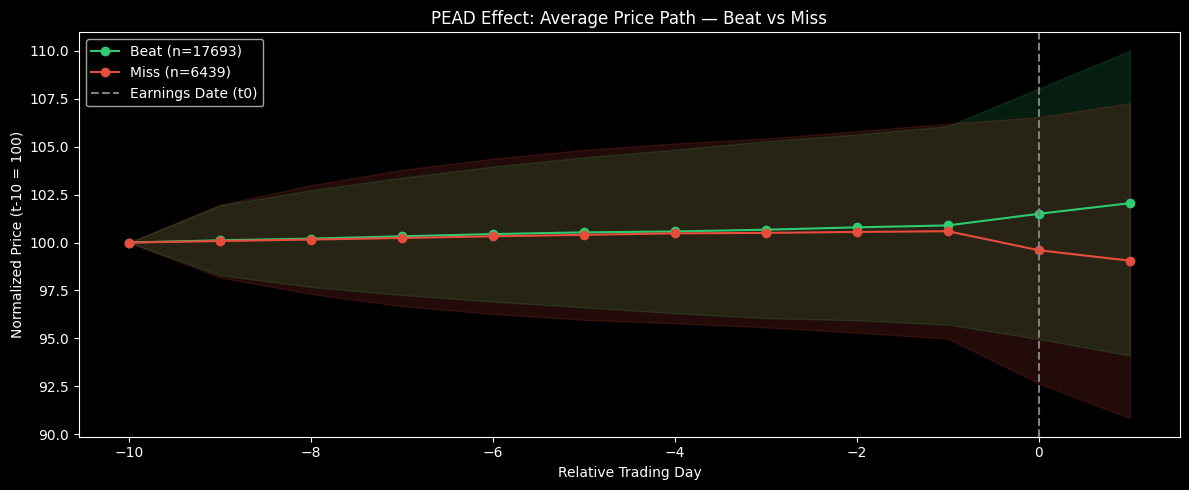

In [17]:
# PEAD: average price path by beat vs miss
close_cols = sorted(
    [c for c in modeling.columns if re.match(r"^close_t[+-]?\d+$", c)],
    key=lambda c: int(re.search(r"(-?\d+)$", c).group(1))
)
days = list(range(-10, 2))

fig, ax = plt.subplots(figsize=(12, 5))

for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat") == flag)

    prices = group.select(close_cols).to_numpy()
    base = prices[:, 0:1]
    mask = (base > 0).flatten()
    normalized = (prices[mask] / base[mask]) * 100

    avg_path = np.mean(normalized, axis=0)
    std_path = np.std(normalized, axis=0)

    ax.plot(days, avg_path, marker="o", label=f"{label} (n={len(normalized)})", color=color)
    ax.fill_between(days, avg_path - std_path, avg_path + std_path, alpha=0.15, color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date (t0)")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Normalized Price (t-10 = 100)")
ax.set_title("PEAD Effect: Average Price Path — Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()

### Announcement-Day & Post-Announcement Returns


Returns by earnings surprise direction:
shape: (2, 6)
┌──────┬───────────────┬────────────────┬───────────────┬────────────────┬───────┐
│ beat ┆ avg_return_t0 ┆ avg_return_t+1 ┆ std_return_t0 ┆ std_return_t+1 ┆ count │
│ ---  ┆ ---           ┆ ---            ┆ ---           ┆ ---            ┆ ---   │
│ i8   ┆ f64           ┆ f64            ┆ f64           ┆ f64            ┆ u32   │
╞══════╪═══════════════╪════════════════╪═══════════════╪════════════════╪═══════╡
│ 0    ┆ -0.009826     ┆ -0.005391      ┆ 0.043095      ┆ 0.045654       ┆ 6439  │
│ 1    ┆ 0.006064      ┆ 0.005475       ┆ 0.039817      ┆ 0.044773       ┆ 17693 │
└──────┴───────────────┴────────────────┴───────────────┴────────────────┴───────┘


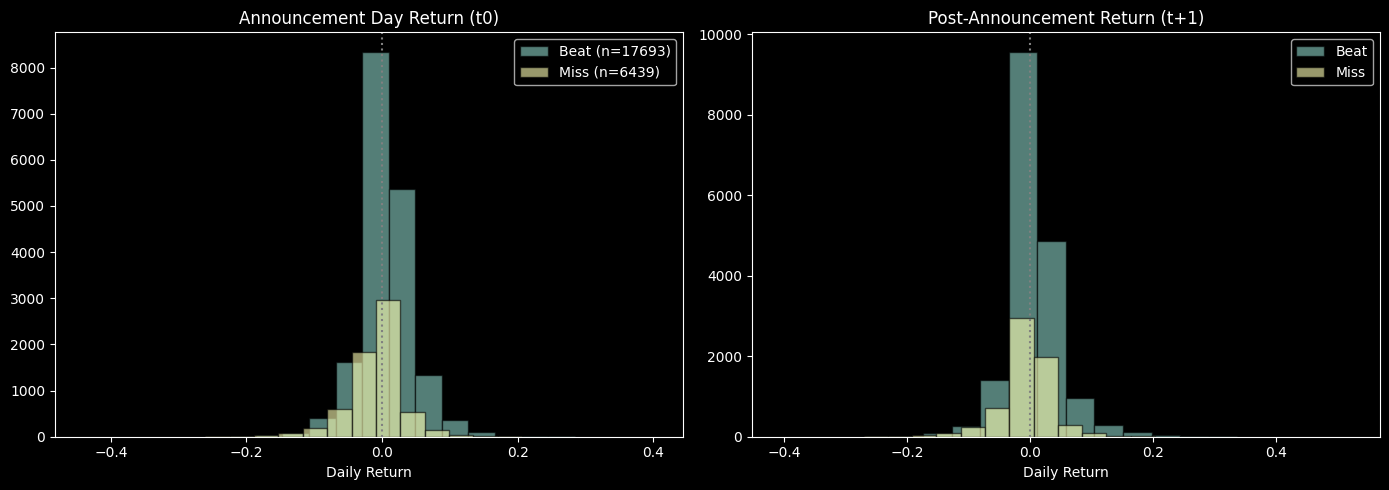

In [18]:
# Return distributions by beat/miss
return_summary = modeling.group_by("beat").agg([
    pl.col("daily_return_t0").mean().alias("avg_return_t0"),
    pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
    pl.col("daily_return_t0").std().alias("std_return_t0"),
    pl.col("daily_return_t+1").std().alias("std_return_t+1"),
    pl.len().alias("count"),
]).sort("beat")
print("Returns by earnings surprise direction:")
print(return_summary)

beats = modeling.filter(pl.col("beat") == 1)
misses = modeling.filter(pl.col("beat") == 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(beats["daily_return_t0"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Beat (n={beats.shape[0]})", edgecolor="black")
axes[0].hist(misses["daily_return_t0"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Miss (n={misses.shape[0]})", edgecolor="black")
axes[0].axvline(x=0, color="gray", linestyle=":")
axes[0].set_title("Announcement Day Return (t0)")
axes[0].set_xlabel("Daily Return")
axes[0].legend()

axes[1].hist(beats["daily_return_t+1"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Beat", edgecolor="black")
axes[1].hist(misses["daily_return_t+1"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Miss", edgecolor="black")
axes[1].axvline(x=0, color="gray", linestyle=":")
axes[1].set_title("Post-Announcement Return (t+1)")
axes[1].set_xlabel("Daily Return")
axes[1].legend()

plt.tight_layout()
plt.show()


### Surprise Magnitude vs Return


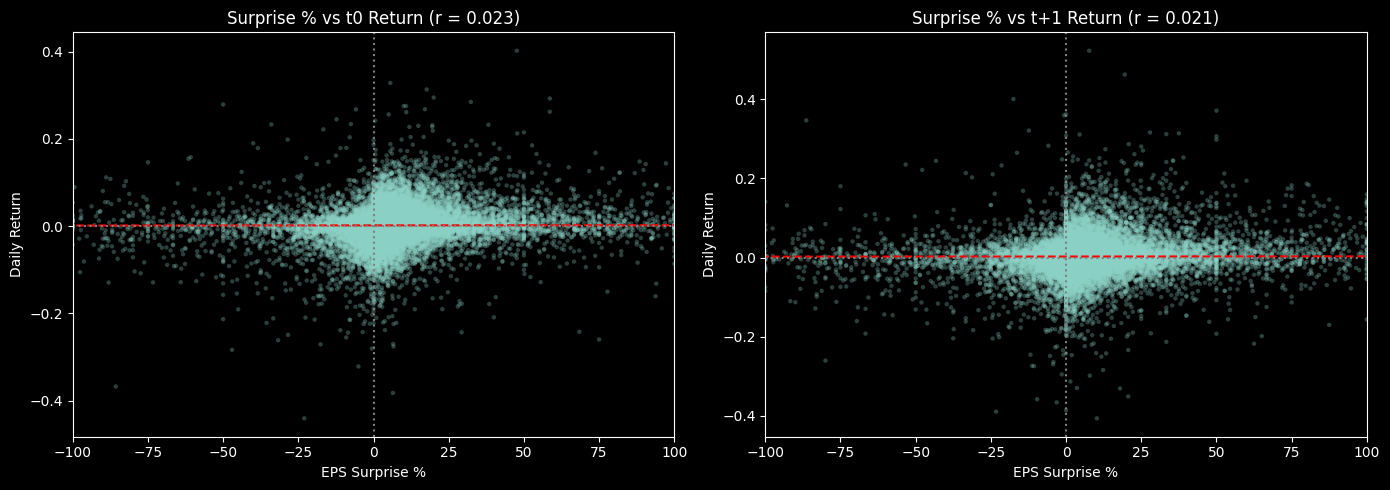

In [19]:
# Larger suprise means larger return?
scatter_data = modeling.select(
    "surprisePercentage", "daily_return_t0", "daily_return_t+1"
).drop_nulls()

sp = scatter_data["surprisePercentage"].to_list()
r0 = scatter_data["daily_return_t0"].to_list()
r1 = scatter_data["daily_return_t+1"].to_list()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ret, title in [
    (axes[0], r0, "Surprise % vs t0 Return"),
    (axes[1], r1, "Surprise % vs t+1 Return"),
]:
    ax.scatter(sp, ret, alpha=0.3, s=10, edgecolors="none")
    z = np.polyfit(sp, ret, 1)
    x_line = np.linspace(min(sp), max(sp), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="red", linestyle="--")
    r_val = np.corrcoef(sp, ret)[0, 1]
    ax.set_title(f"{title} (r = {r_val:.3f})")
    ax.set_xlabel("EPS Surprise %")
    ax.set_ylabel("Daily Return")
    ax.set_xlim(-100, 100)  # extreme surprise outliers
    ax.axhline(y=0, color="gray", linestyle=":")
    ax.axvline(x=0, color="gray", linestyle=":")

plt.tight_layout()
plt.show()

### Volume Profile - Beat vs Miss


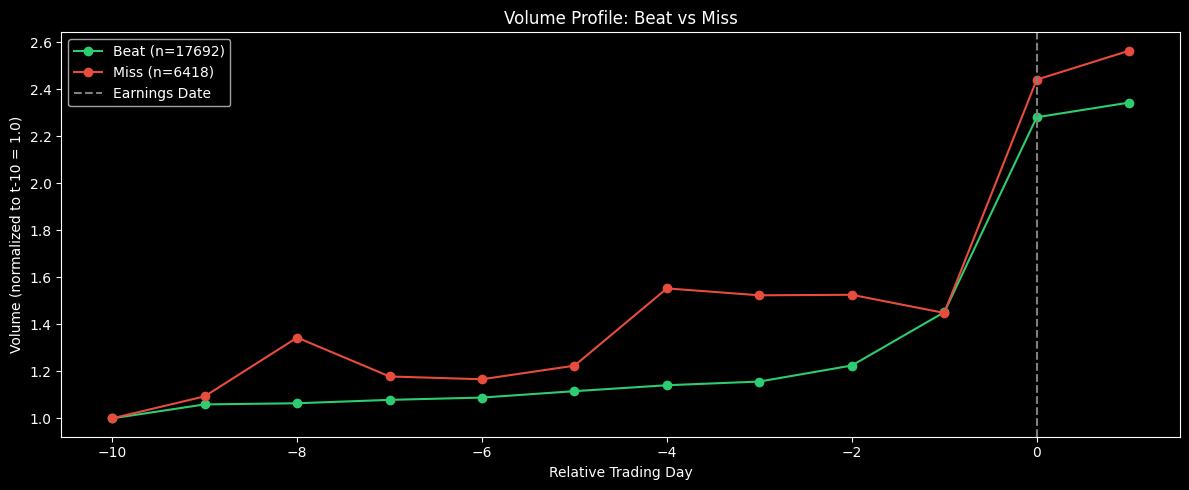

In [20]:
# Normalized volume by beat/miss
days = list(range(-10, 2))  # t-10 to t+1

volume_cols = sorted(
    [c for c in modeling.columns if re.match(r"^volume_t[+-]?\d+$", c)],
    key=lambda c: int(re.search(r"(-?\d+)$", c).group(1))
)

fig, ax = plt.subplots(figsize=(12, 5))

for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat") == flag)

    vols = group.select(volume_cols).to_numpy().astype(float)
    base = vols[:, 0:1]
    mask = (base > 0).flatten()
    normalized = vols[mask] / base[mask]

    avg_vol = np.mean(normalized, axis=0)
    ax.plot(days, avg_vol, marker="o", label=f"{label} (n={len(normalized)})", color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Volume (normalized to t-10 = 1.0)")
ax.set_title("Volume Profile: Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()

### Report Timing - Pre-Market vs Post-Market


Return behavior by announcement timing:
shape: (2, 5)
┌─────────────┬───────┬───────────────┬────────────────┬───────────┐
│ reportTime  ┆ count ┆ avg_return_t0 ┆ avg_return_t+1 ┆ beat_rate │
│ ---         ┆ ---   ┆ ---           ┆ ---            ┆ ---       │
│ str         ┆ u32   ┆ f64           ┆ f64            ┆ f64       │
╞═════════════╪═══════╪═══════════════╪════════════════╪═══════════╡
│ post-market ┆ 9783  ┆ 0.00118       ┆ 0.004743       ┆ 0.726158  │
│ pre-market  ┆ 14349 ┆ 0.002264      ┆ 0.001098       ┆ 0.737961  │
└─────────────┴───────┴───────────────┴────────────────┴───────────┘


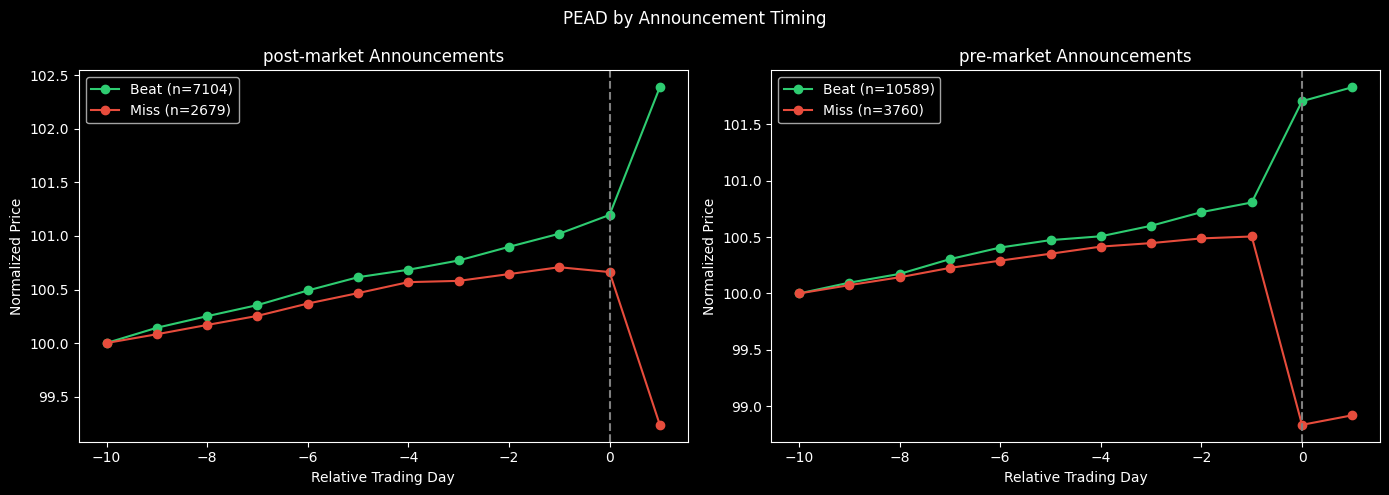

In [21]:
# Report timing analysis
days = list(range(-10, 2))
close_cols = sorted(
    [c for c in modeling.columns if re.match(r"^close_t[+-]?\d+$", c)],
    key=lambda c: int(re.search(r"(-?\d+)$", c).group(1))
)

timing = modeling.group_by("reportTime").agg([
    pl.len().alias("count"),
    pl.col("daily_return_t0").mean().alias("avg_return_t0"),
    pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
    pl.col("beat").mean().alias("beat_rate"),
]).sort("reportTime")
print("Return behavior by announcement timing:")
print(timing)

timing_vals = modeling["reportTime"].drop_nulls().unique().sort().to_list()
fig, axes = plt.subplots(1, len(timing_vals), figsize=(7 * len(timing_vals), 5))
axes = [axes] if len(timing_vals) == 1 else list(axes)

for ax, timing_val in zip(axes, timing_vals):
    group = modeling.filter(pl.col("reportTime") == timing_val)
    for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
        sub = group.filter(pl.col("beat") == flag)
        prices = sub.select(close_cols).to_numpy()
        base = prices[:, 0:1]
        mask = (base > 0).flatten()
        normalized = (prices[mask] / base[mask]) * 100
        if len(normalized) > 0:
            ax.plot(days, np.mean(normalized, axis=0), marker="o",
                    label=f"{label} (n={len(normalized)})", color=color)
    ax.axvline(x=0, color="gray", linestyle="--")
    ax.set_title(f"{timing_val} Announcements")
    ax.set_xlabel("Relative Trading Day")
    ax.set_ylabel("Normalized Price")
    ax.legend()

plt.suptitle("PEAD by Announcement Timing")
plt.tight_layout()
plt.show()

### Fiscal Quarter Seasonality

Earnings behavior by fiscal quarter:
shape: (4, 6)
┌─────────┬───────┬───────────┬───────────────┬────────────────┬──────────────┐
│ quarter ┆ count ┆ beat_rate ┆ avg_return_t0 ┆ avg_return_t+1 ┆ avg_surprise │
│ ---     ┆ ---   ┆ ---       ┆ ---           ┆ ---            ┆ ---          │
│ str     ┆ u32   ┆ f64       ┆ f64           ┆ f64            ┆ f64          │
╞═════════╪═══════╪═══════════╪═══════════════╪════════════════╪══════════════╡
│ Q1      ┆ 6291  ┆ 0.740582  ┆ 0.00092       ┆ 0.002321       ┆ 0.102486     │
│ Q2      ┆ 5803  ┆ 0.746683  ┆ 0.00148       ┆ 0.002349       ┆ 0.106614     │
│ Q3      ┆ 5808  ┆ 0.74759   ┆ 0.00231       ┆ 0.003244       ┆ 0.09227      │
│ Q4      ┆ 6230  ┆ 0.699679  ┆ 0.002607      ┆ 0.002421       ┆ 0.087782     │
└─────────┴───────┴───────────┴───────────────┴────────────────┴──────────────┘


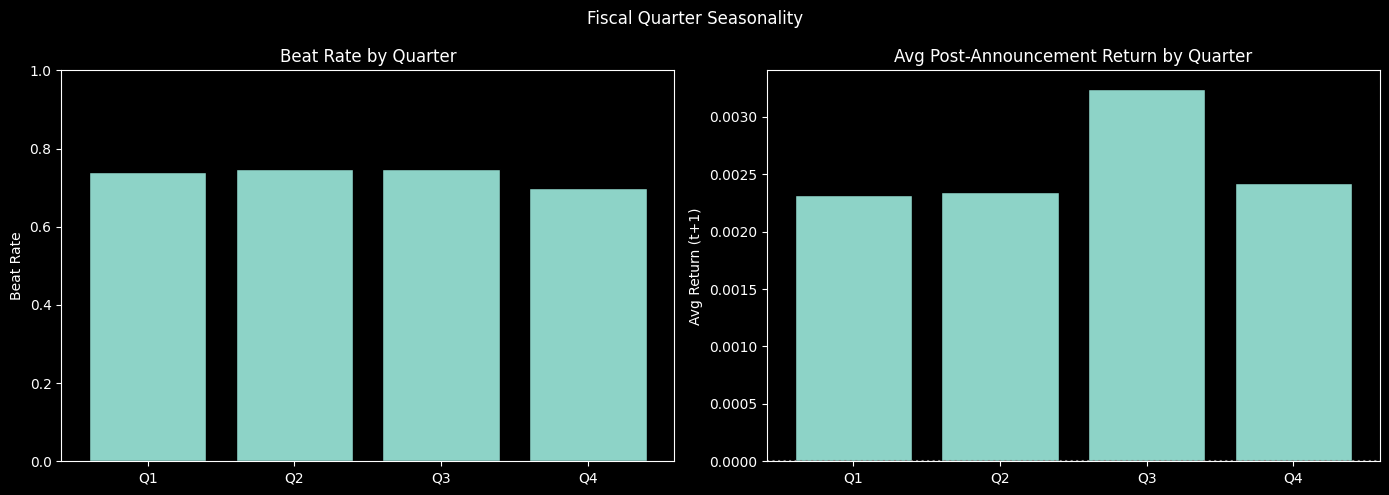

In [22]:
if "av_quarter" not in modeling.columns:
    print("av_quarter column not found — skipping seasonality analysis")
else:
    q_analysis = modeling.with_columns(
        pl.col("av_quarter").str.slice(-2).alias("quarter")
    ).group_by("quarter").agg([
        pl.len().alias("count"),
        pl.col("beat").mean().alias("beat_rate"),
        pl.col("daily_return_t0").mean().alias("avg_return_t0"),
        pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
        pl.col("surprise").mean().alias("avg_surprise"),
    ]).sort("quarter")

    print("Earnings behavior by fiscal quarter:")
    print(q_analysis)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    quarters = q_analysis["quarter"].to_list()
    axes[0].bar(quarters, q_analysis["beat_rate"].to_list(), edgecolor="black")
    axes[0].set_title("Beat Rate by Quarter")
    axes[0].set_ylabel("Beat Rate")
    axes[0].set_ylim(0, 1)

    axes[1].bar(quarters, q_analysis["avg_return_t+1"].to_list(), edgecolor="black")
    axes[1].set_title("Avg Post-Announcement Return by Quarter")
    axes[1].set_ylabel("Avg Return (t+1)")
    axes[1].axhline(y=0, color="gray", linestyle=":")

    plt.suptitle("Fiscal Quarter Seasonality")
    plt.tight_layout()
    plt.show()

### Volatility (ATR) Profile - Beat vs Miss


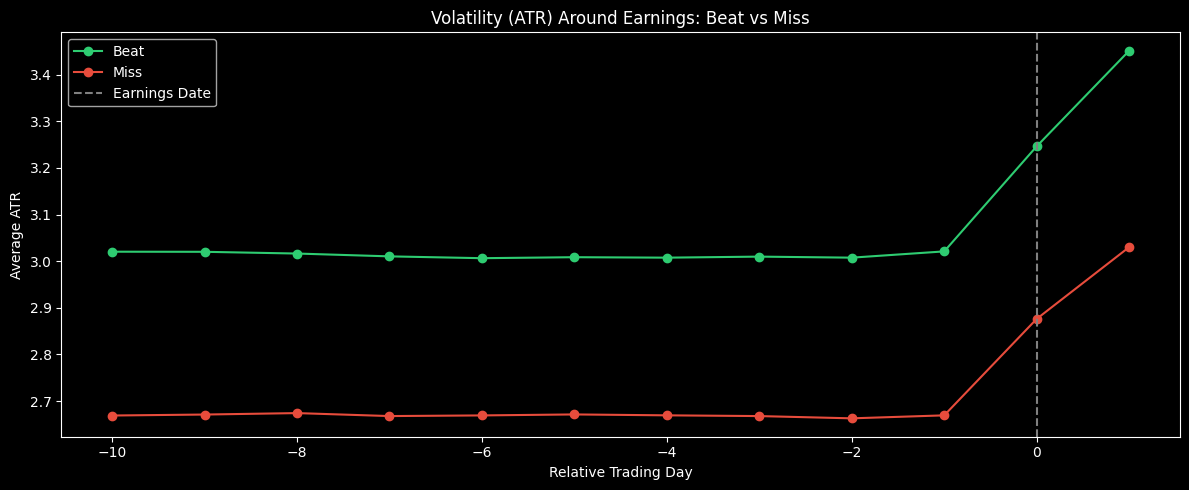

In [23]:
# ATR profile around earnings
days = list(range(-10, 2))
atr_cols = sorted(
    [c for c in modeling.columns if re.match(r"^atr_t[+-]?\d+$", c)],
    key=lambda c: int(re.search(r"(-?\d+)$", c).group(1))
)

fig, ax = plt.subplots(figsize=(12, 5))
for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat") == flag)
    avg_atr = group.select(atr_cols).to_pandas().mean()
    ax.plot(days, avg_atr.values, marker="o", label=label, color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Average ATR")
ax.set_title("Volatility (ATR) Around Earnings: Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()

### RSI, MACD, EPS trends, and EPS feature distributions.


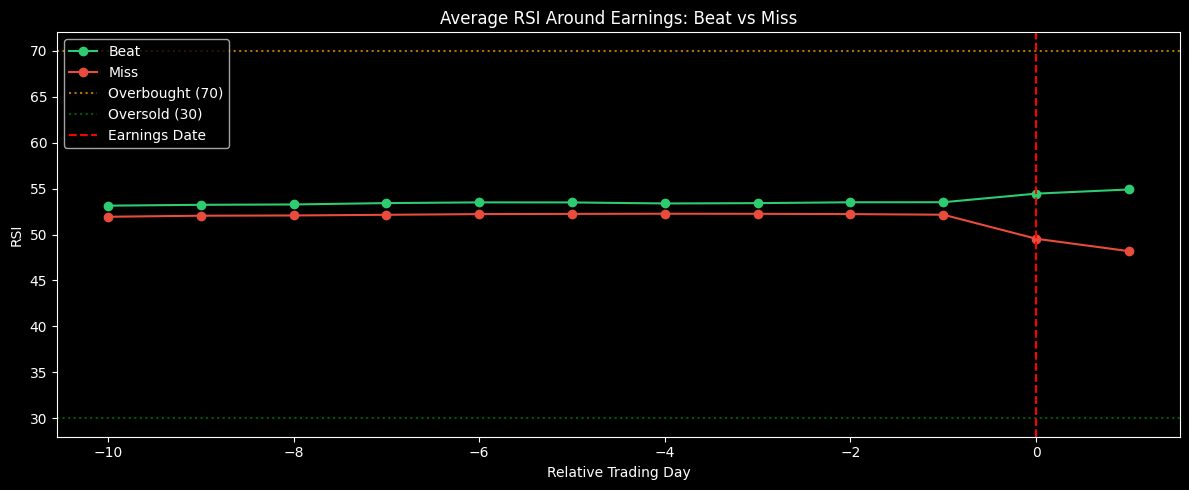

In [24]:
# RSI around earnings
days = list(range(-10, 2))
rsi_cols = sorted(
    [c for c in modeling.columns if re.match(r"^rsi_t[+-]?\d+$", c)],
    key=lambda c: int(re.search(r"(-?\d+)$", c).group(1))
)

fig, ax = plt.subplots(figsize=(12, 5))

for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat") == flag)
    avg_rsi = group.select(rsi_cols).to_pandas().mean()
    ax.plot(days, avg_rsi.values, marker="o", label=label, color=color)

ax.axhline(y=70, color="orange", linestyle=":", alpha=0.7, label="Overbought (70)")
ax.axhline(y=30, color="green", linestyle=":", alpha=0.7, label="Oversold (30)")
ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date")
ax.set_title("Average RSI Around Earnings: Beat vs Miss")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("RSI")
ax.legend()
plt.tight_layout()
plt.show()

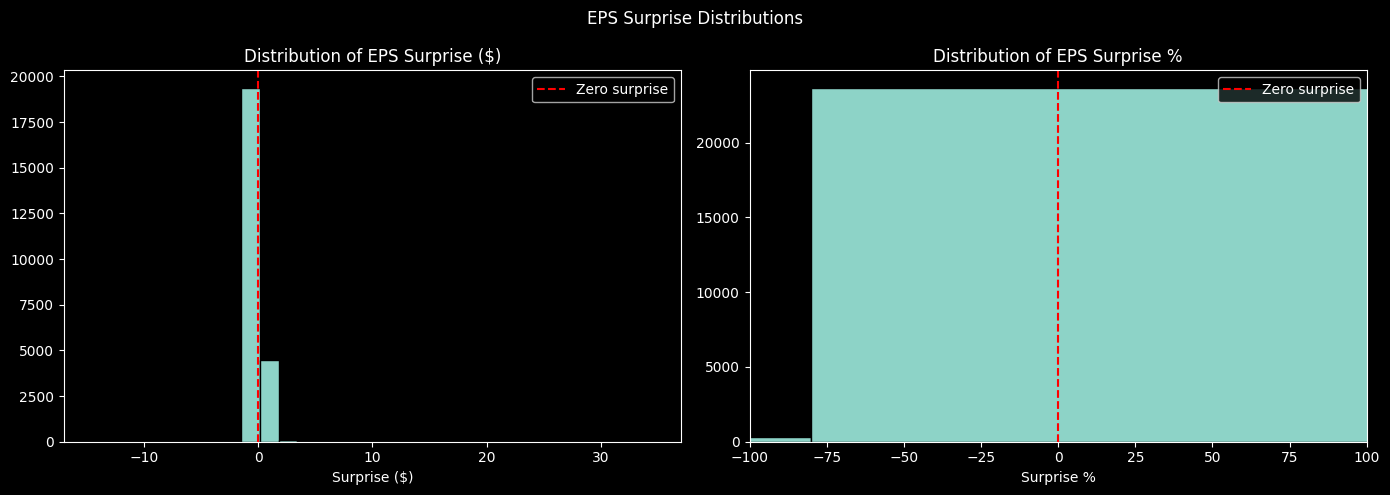

In [25]:
# EPS surprise distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(modeling["surprise"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[0].axvline(x=0, color="red", linestyle="--", label="Zero surprise")
axes[0].set_title("Distribution of EPS Surprise ($)")
axes[0].set_xlabel("Surprise ($)")
axes[0].legend()

axes[1].hist(modeling["surprisePercentage"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[1].axvline(x=0, color="red", linestyle="--", label="Zero surprise")
axes[1].set_title("Distribution of EPS Surprise %")
axes[1].set_xlabel("Surprise %")
axes[1].set_xlim(-100, 100)  # clip extreme outliers for readability
axes[1].legend()

plt.suptitle("EPS Surprise Distributions")
plt.tight_layout()
plt.show()

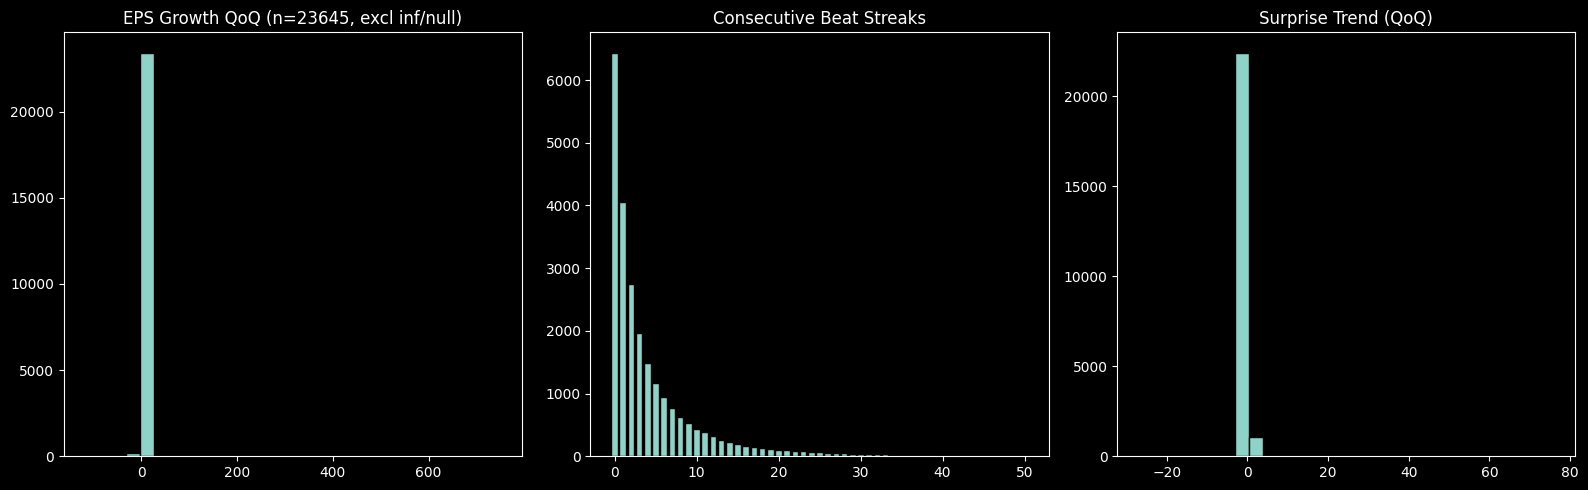

eps_growth: 7 infinite values (prior EPS was $0.00)


In [26]:
# EPS feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Filter out inf and null
eps_growth_clean = modeling["eps_growth"].filter(
    modeling["eps_growth"].is_finite() & modeling["eps_growth"].is_not_null()
).to_list()

axes[0].hist(eps_growth_clean, bins=30, edgecolor="black")
axes[0].set_title(f"EPS Growth QoQ (n={len(eps_growth_clean)}, excl inf/null)")

vc = modeling["consecutive_beats"].drop_nulls().value_counts().sort("consecutive_beats")
axes[1].bar(vc["consecutive_beats"].to_list(), vc["count"].to_list(), edgecolor="black")
axes[1].set_title("Consecutive Beat Streaks")

axes[2].hist(modeling["surprise_trend"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[2].set_title("Surprise Trend (QoQ)")
plt.tight_layout()
plt.show()

# Report how many infs were excluded
n_inf = modeling["eps_growth"].is_infinite().sum()
print(f"eps_growth: {n_inf} infinite values (prior EPS was $0.00)")

Yearly trends:
shape: (13, 5)
┌──────┬─────────────┬───────────┬───────────────────┬──────────────────┐
│ year ┆ event_count ┆ beat_rate ┆ avg_target_return ┆ avg_surprise_pct │
│ ---  ┆ ---         ┆ ---       ┆ ---               ┆ ---              │
│ i32  ┆ u32         ┆ f64       ┆ f64               ┆ f64              │
╞══════╪═════════════╪═══════════╪═══════════════════╪══════════════════╡
│ 2014 ┆ 1831        ┆ 0.66521   ┆ 0.009957          ┆ 8.320067         │
│ 2015 ┆ 1853        ┆ 0.672963  ┆ 0.00476           ┆ 5.339666         │
│ 2016 ┆ 1869        ┆ 0.692349  ┆ 0.008751          ┆ 9.84834          │
│ 2017 ┆ 1896        ┆ 0.712553  ┆ 0.003263          ┆ 13.749419        │
│ 2018 ┆ 1904        ┆ 0.771534  ┆ 0.004395          ┆ 14.569176        │
│ …    ┆ …           ┆ …         ┆ …                 ┆ …                │
│ 2022 ┆ 1981        ┆ 0.726401  ┆ 0.007047          ┆ -0.064033        │
│ 2023 ┆ 1991        ┆ 0.74887   ┆ 0.002385          ┆ 6.035214         │
│ 2024 ┆

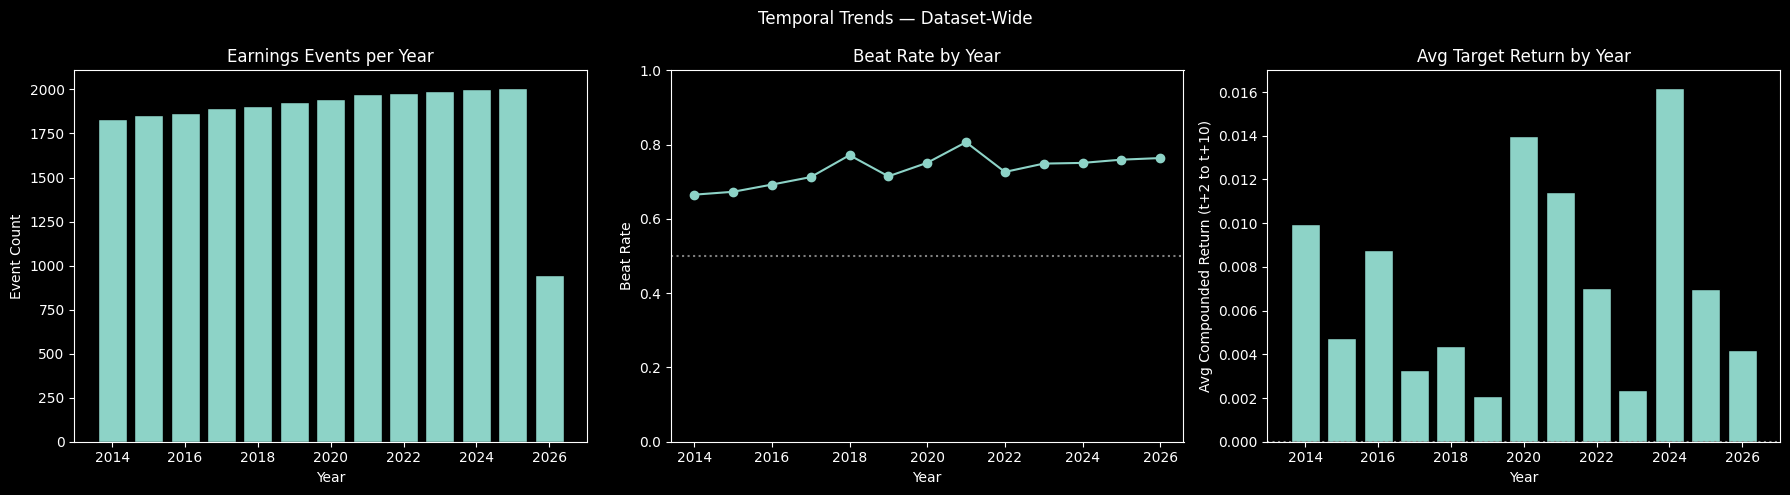

In [27]:
# Temporal trends — dataset-wide
modeling = modeling.with_columns(
    pl.col("earnings_date").dt.year().alias("year")
)

yearly = modeling.group_by("year").agg([
    pl.len().alias("event_count"),
    pl.col("beat").mean().alias("beat_rate"),
    pl.col("target_return").mean().alias("avg_target_return"),
    pl.col("surprisePercentage").mean().alias("avg_surprise_pct"),
]).sort("year")

print("Yearly trends:")
print(yearly)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(yearly["year"].to_list(), yearly["event_count"].to_list(), edgecolor="black")
axes[0].set_title("Earnings Events per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Event Count")

axes[1].plot(yearly["year"].to_list(), yearly["beat_rate"].to_list(), marker="o")
axes[1].axhline(y=0.5, color="gray", linestyle=":")
axes[1].set_title("Beat Rate by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Beat Rate")
axes[1].set_ylim(0, 1)

axes[2].bar(yearly["year"].to_list(), yearly["avg_target_return"].to_list(), edgecolor="black")
axes[2].axhline(y=0, color="gray", linestyle=":")
axes[2].set_title("Avg Target Return by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Avg Compounded Return (t+2 to t+10)")

plt.suptitle("Temporal Trends — Dataset-Wide")
plt.tight_layout()
plt.show()

### PEAD by Sector

shape: (11, 6)
┌────────────────────────┬────────┬───────────┬───────────┬──────────────────┬─────────────────────┐
│ sector                 ┆ events ┆ beat_rate ┆ avg_drift ┆ avg_surprise_pct ┆ avg_announce_return │
│ ---                    ┆ ---    ┆ ---       ┆ ---       ┆ ---              ┆ ---                 │
│ str                    ┆ u32    ┆ f64       ┆ f64       ┆ f64              ┆ f64                 │
╞════════════════════════╪════════╪═══════════╪═══════════╪══════════════════╪═════════════════════╡
│ Technology             ┆ 3892   ┆ 0.839928  ┆ 0.009532  ┆ 16.013341        ┆ 0.002732            │
│ Industrials            ┆ 3520   ┆ 0.759659  ┆ 0.009575  ┆ 13.132257        ┆ 0.002931            │
│ Financial Services     ┆ 3425   ┆ 0.731095  ┆ 0.010799  ┆ 6.059882         ┆ 0.001061            │
│ Healthcare             ┆ 2849   ┆ 0.809758  ┆ 0.005407  ┆ 8.695689         ┆ 0.001535            │
│ Consumer Cyclical      ┆ 2586   ┆ 0.697216  ┆ 0.006466  ┆ 11.825256       

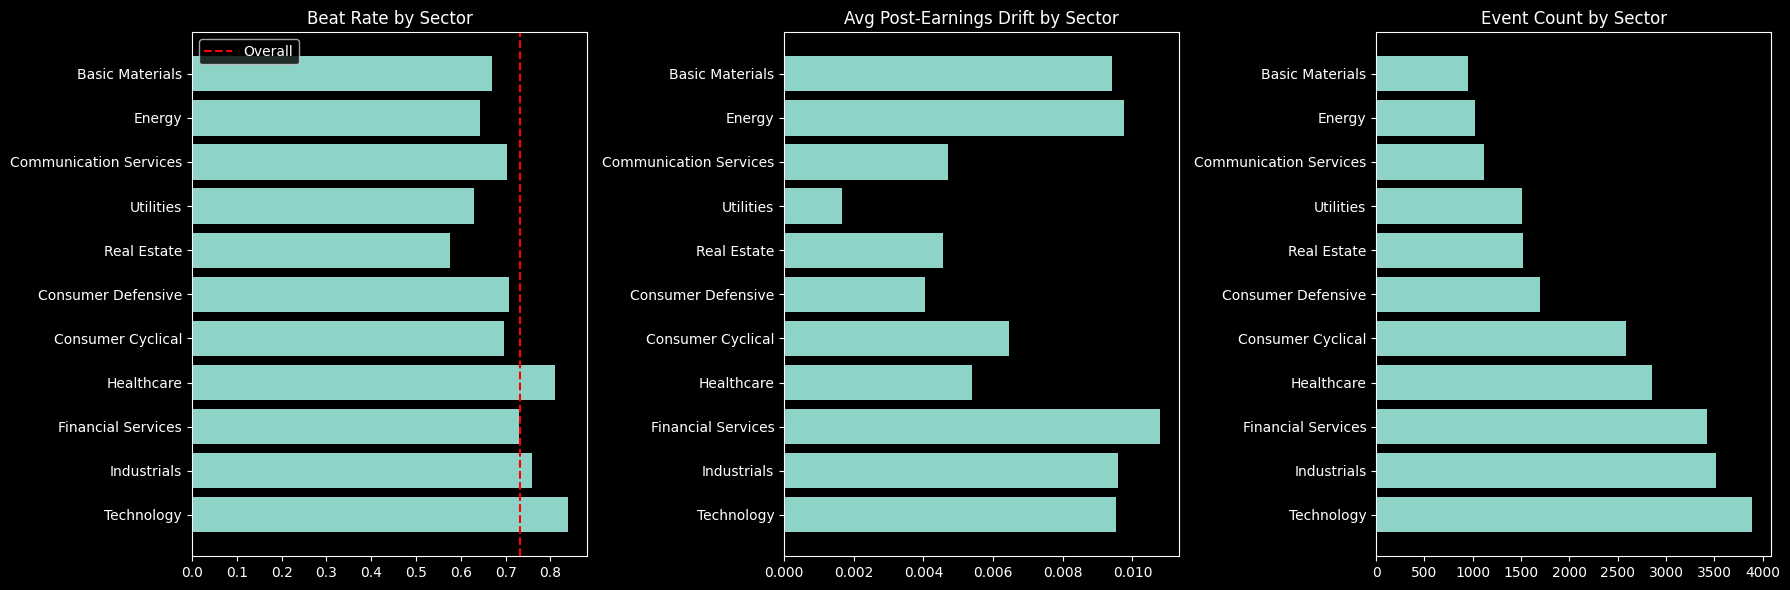

In [28]:
# Sector-level analysis
sector_analysis = modeling.filter(pl.col("sector").is_not_null()).group_by("sector").agg([
    pl.len().alias("events"),
    pl.col("beat").mean().alias("beat_rate"),
    pl.col("target_return").mean().alias("avg_drift"),
    pl.col("surprisePercentage").mean().alias("avg_surprise_pct"),
    pl.col("daily_return_t0").mean().alias("avg_announce_return"),
]).sort("events", descending=True)

print(sector_analysis)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sectors = sector_analysis["sector"].to_list()
x = range(len(sectors))

axes[0].barh(sectors, sector_analysis["beat_rate"].to_list())
axes[0].set_title("Beat Rate by Sector")
axes[0].axvline(x=modeling["beat"].mean(), color="red", linestyle="--", label="Overall")
axes[0].legend()

axes[1].barh(sectors, sector_analysis["avg_drift"].to_list())
axes[1].set_title("Avg Post-Earnings Drift by Sector")
axes[1].axvline(x=0, color="red", linestyle="--")

axes[2].barh(sectors, sector_analysis["events"].to_list())
axes[2].set_title("Event Count by Sector")

plt.tight_layout()
plt.show()

## Feature Importance - Predictive Signal Assessment

### Beat vs Miss Feature Comparison

In [29]:
# Beat vs miss mean comparison
compare_cols = [c for c in modeling.columns if c.endswith("_t0")] + [
    "surprise", "surprisePercentage"
]
compare_cols = [c for c in compare_cols if c in modeling.columns]

beat_means = modeling.filter(pl.col("beat") == 1).select(compare_cols).mean()
miss_means = modeling.filter(pl.col("beat") == 0).select(compare_cols).mean()

rows = []
for col in compare_cols:
    b, m = beat_means[col][0], miss_means[col][0]
    pct = 100 * (b - m) / abs(m) if m and m != 0 and b is not None else None
    rows.append({
        "feature": col,
        "beat_mean": round(b, 4) if b else None,
        "miss_mean": round(m, 4) if m else None,
        "pct_diff": round(pct, 1) if pct else None
    })

print("Feature means: Beat vs Miss (sorted by % difference)")
print(pl.DataFrame(rows).sort("pct_diff", descending=True, nulls_last=True))

Feature means: Beat vs Miss (sorted by % difference)
shape: (23, 4)
┌───────────────────┬───────────┬───────────┬──────────┐
│ feature           ┆ beat_mean ┆ miss_mean ┆ pct_diff │
│ ---               ┆ ---       ┆ ---       ┆ ---      │
│ str               ┆ f64       ┆ f64       ┆ f64      │
╞═══════════════════╪═══════════╪═══════════╪══════════╡
│ adx_t0            ┆ NaN       ┆ NaN       ┆ NaN      │
│ atr_t0            ┆ NaN       ┆ NaN       ┆ NaN      │
│ bb_pct_b_t0       ┆ NaN       ┆ NaN       ┆ NaN      │
│ bb_width_t0       ┆ NaN       ┆ NaN       ┆ NaN      │
│ macd_t0           ┆ NaN       ┆ NaN       ┆ NaN      │
│ …                 ┆ …         ┆ …         ┆ …        │
│ high_t0           ┆ 128.6418  ┆ 109.3161  ┆ 17.7     │
│ open_t0           ┆ 126.0507  ┆ 107.1646  ┆ 17.6     │
│ obv_t0            ┆ 0.9624    ┆ 0.8421    ┆ 14.3     │
│ intraday_range_t0 ┆ 0.0395    ┆ 0.0406    ┆ -2.7     │
│ volume_t0         ┆ 1.1145e7  ┆ 1.1756e7  ┆ -5.2     │
└───────────────────

### Mutual Information Ranking


Clean rows for MI: 23452
Mutual Information Ranking:
shape: (24, 3)
┌───────────────────┬─────────┬─────────────────────┐
│ feature           ┆ MI_beat ┆ MI_target_direction │
│ ---               ┆ ---     ┆ ---                 │
│ str               ┆ f64     ┆ f64                 │
╞═══════════════════╪═════════╪═════════════════════╡
│ low_t0            ┆ 0.0125  ┆ 0.0073              │
│ sma50_ratio_t0    ┆ 0.0141  ┆ 0.006               │
│ open_t0           ┆ 0.0064  ┆ 0.0052              │
│ volume_change_t0  ┆ 0.0106  ┆ 0.0051              │
│ rsi_t0            ┆ 0.0184  ┆ 0.0041              │
│ …                 ┆ …       ┆ …                   │
│ obv_t0            ┆ 0.0052  ┆ 0.0                 │
│ roc_t0            ┆ 0.0086  ┆ 0.0                 │
│ sma200_ratio_t0   ┆ 0.0111  ┆ 0.0                 │
│ vwap_ratio_t0     ┆ 0.0091  ┆ 0.0                 │
│ consecutive_beats ┆ 0.5771  ┆ 0.0                 │
└───────────────────┴─────────┴─────────────────────┘


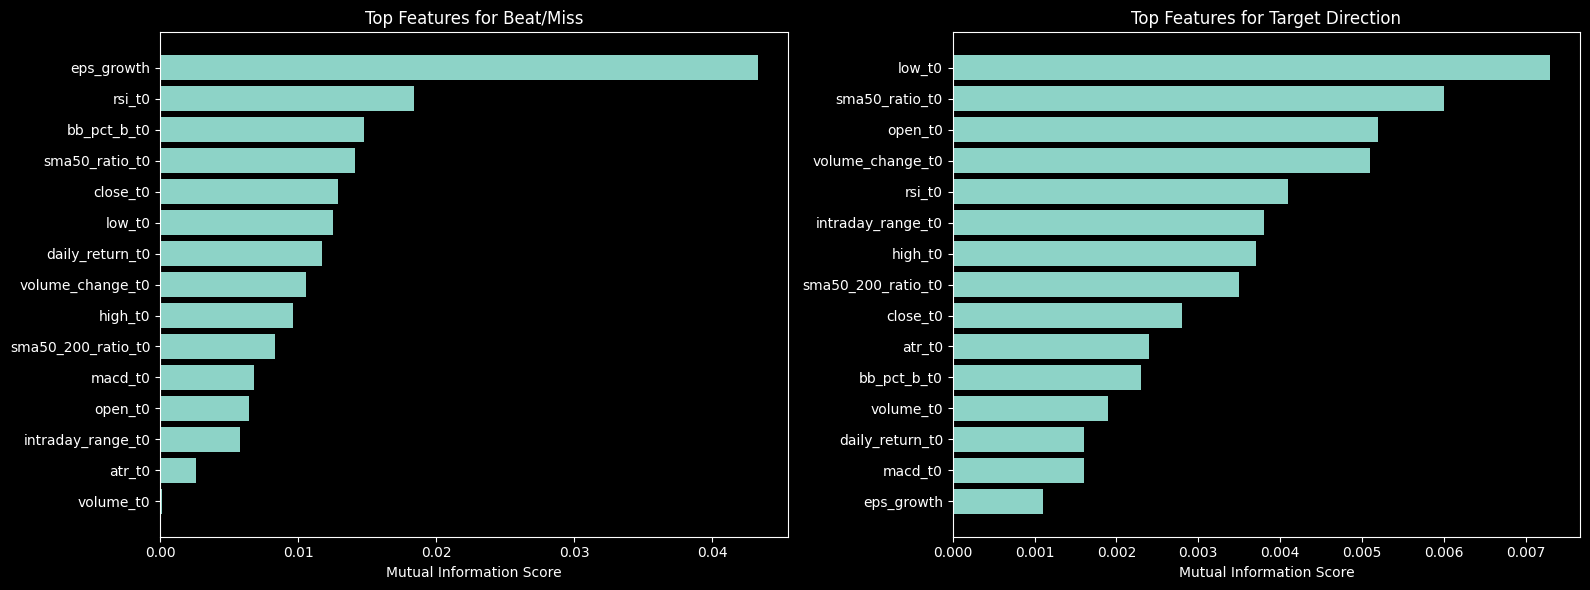

In [30]:
# Mutual information for beat/miss and target direction
from sklearn.feature_selection import mutual_info_classif

mi_cols = [c for c in modeling.columns if c.endswith("_t0")] + [
    "eps_growth", "surprise_trend", "consecutive_beats"
]
mi_cols = [c for c in mi_cols if c in modeling.columns]

# Handle nulls and infs
mi_data = (
    modeling.select(mi_cols + ["beat", "target_direction"])
    .with_columns([
        pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
        for c in mi_cols
    ])
    .with_columns([pl.col(c).fill_nan(None) for c in mi_cols])  
    .drop_nulls()
    .to_pandas()
    .reset_index(drop=True)
)

print(f"Clean rows for MI: {len(mi_data)}")

X_mi = mi_data[mi_cols].values

# MI against beat
mi_beat = mutual_info_classif(X_mi, mi_data["beat"].values, random_state=42)
# MI against target_direction
mi_target = mutual_info_classif(X_mi, mi_data["target_direction"].values, random_state=42)

mi_df = pl.DataFrame({
    "feature": mi_cols,
    "MI_beat": [round(s, 4) for s in mi_beat],
    "MI_target_direction": [round(s, 4) for s in mi_target],
}).sort("MI_target_direction", descending=True)

print("Mutual Information Ranking:")
print(mi_df)

# Plot top 15 for target_direction
top_n = min(15, len(mi_df))
top = mi_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], "MI_beat", "Top Features for Beat/Miss"),
    (axes[1], "MI_target_direction", "Top Features for Target Direction")
]:
    sorted_top = top.sort(col, descending=True)
    ax.barh(range(top_n), sorted_top[col].to_list()[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(sorted_top["feature"].to_list()[::-1])
    ax.set_xlabel("Mutual Information Score")
    ax.set_title(title)

plt.tight_layout()
plt.show()

EPS surprise features rank highest for predicting beat/miss (expected — surprise
defines the label). For `target_direction`, TA indicators at t0 dominate, consistent
with PEAD literature showing that pre-announcement momentum and volatility regime
predict drift magnitude. Features with near-zero MI against `target_direction` are
candidates for removal in Milestone 4 feature selection.

### Pair Plot - Key Features


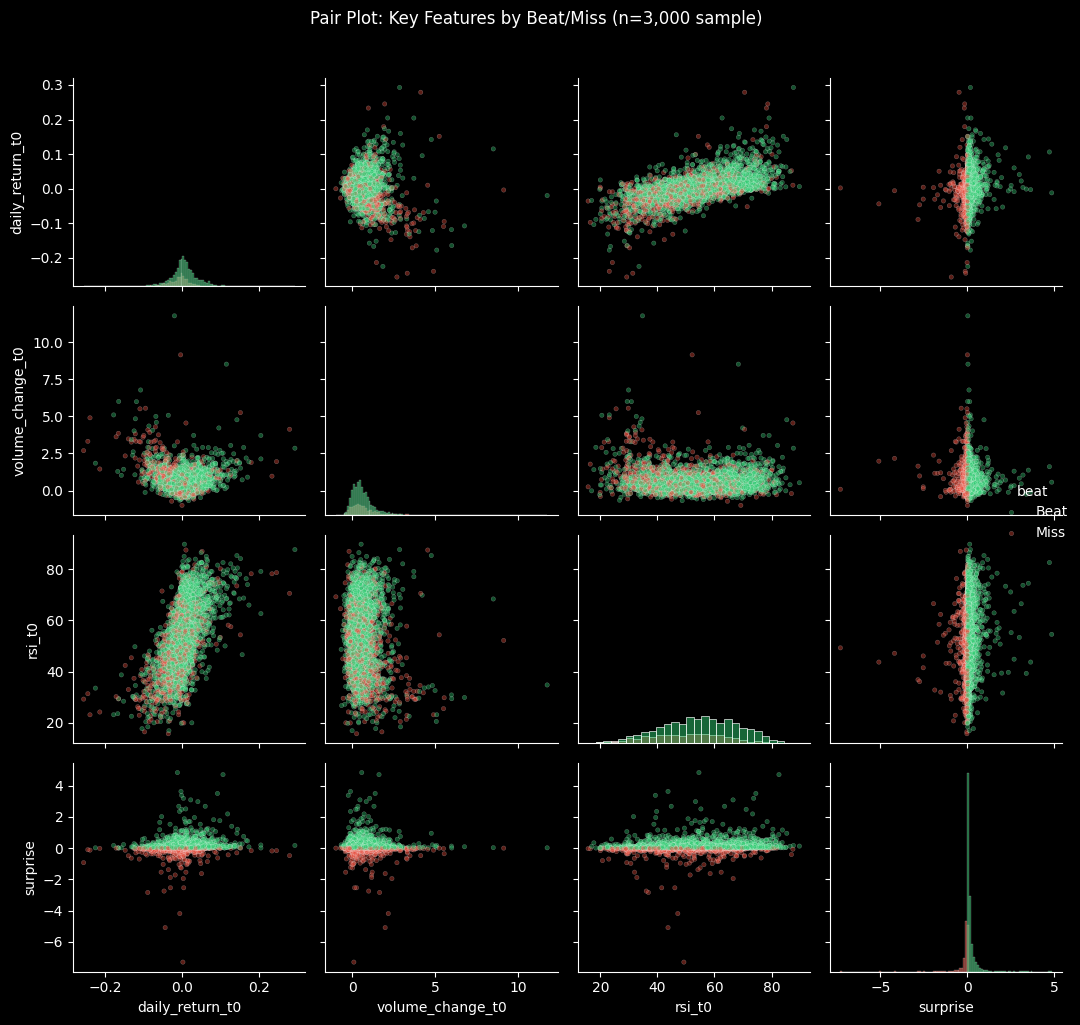

In [31]:
# Pair plot colored by beat/miss
pair_cols = ["daily_return_t0", "volume_change_t0", "rsi_t0", "surprise"]
pair_cols = [c for c in pair_cols if c in modeling.columns]

pair_data = (
    modeling.select(pair_cols + ["beat"])
    .with_columns([
        pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
        for c in pair_cols
    ])
    .drop_nulls()
    .to_pandas()
)

# Sample for readability
pair_data = pair_data.sample(n=min(3000, len(pair_data)), random_state=42)
pair_data["beat"] = pair_data["beat"].map({0: "Miss", 1: "Beat"})

g = sns.pairplot(pair_data, hue="beat", diag_kind="hist",
                 palette={"Beat": "#2ecc71", "Miss": "#e74c3c"},
                 plot_kws={"alpha": 0.4, "s": 10})
g.figure.suptitle("Pair Plot: Key Features by Beat/Miss (n=3,000 sample)", y=1.02)
plt.tight_layout()
plt.show()

## Transcript Analysis

### Transcript Length Distribution


Transcript coverage: 23,185 / 24,132 events (96.1%)

Word count stats:
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ word_count  │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 23185.0     │
│ null_count ┆ 0.0         │
│ mean       ┆ 7615.104248 │
│ std        ┆ 1954.116742 │
│ min        ┆ 0.0         │
│ 25%        ┆ 6584.0      │
│ 50%        ┆ 7847.0      │
│ 75%        ┆ 8871.0      │
│ max        ┆ 23546.0     │
└────────────┴─────────────┘


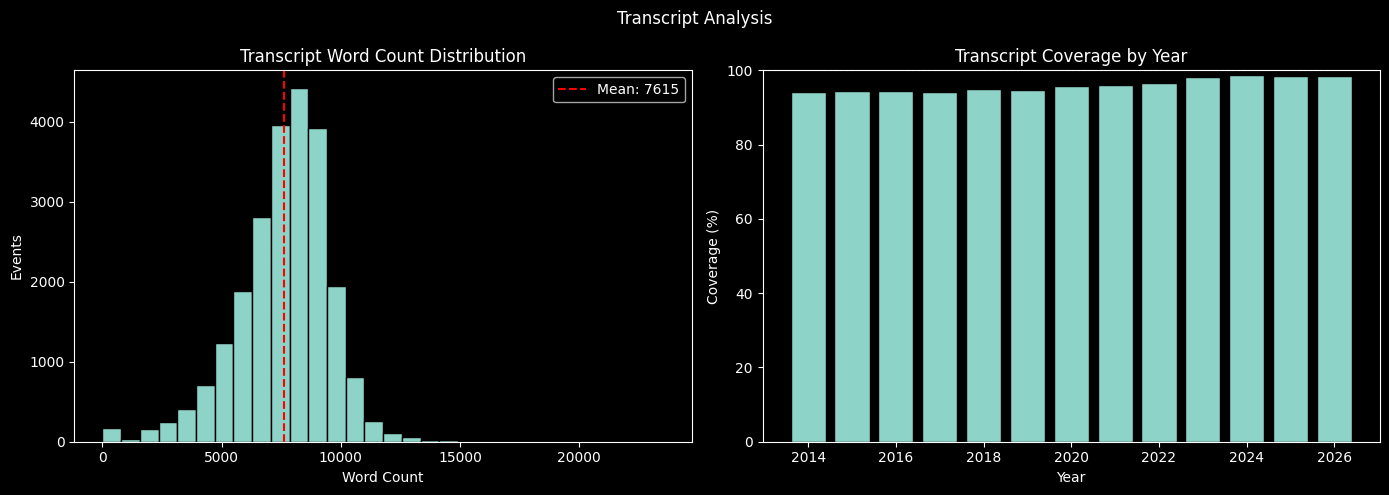

In [32]:
# Transcript length and coverage analysis
transcript_stats = []
for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        transcript_stats.append({
            "symbol": row["symbol"],
            "earnings_date": row["earnings_date"],
            "year": row["earnings_date"].year,
            "has_transcript": False,
            "word_count": None,
        })
        continue
    word_count = sum(
        len(seg.get("content", "").split())
        for seg in transcript
        if isinstance(seg, dict)
    )
    transcript_stats.append({
        "symbol": row["symbol"],
        "earnings_date": row["earnings_date"],
        "year": row["earnings_date"].year,
        "has_transcript": True,
        "word_count": word_count,
    })

tx_df = pl.DataFrame(transcript_stats)

# Coverage stats
total = tx_df.shape[0]
with_tx = tx_df.filter(pl.col("has_transcript")).shape[0]
print(f"Transcript coverage: {with_tx:,} / {total:,} events ({100*with_tx/total:.1f}%)")

tx_valid = tx_df.filter(pl.col("has_transcript"))
print(f"\nWord count stats:")
print(tx_valid.select("word_count").describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist(tx_valid["word_count"].to_list(), bins=30, edgecolor="black")
axes[0].axvline(x=float(tx_valid["word_count"].mean()), color="red",
                linestyle="--", label=f"Mean: {tx_valid['word_count'].mean():.0f}")
axes[0].set_title("Transcript Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Events")
axes[0].legend()

# Transcript availability by year
yearly_coverage = tx_df.group_by("year").agg([
    pl.len().alias("total_events"),
    pl.col("has_transcript").sum().alias("with_transcript"),
]).sort("year")
yearly_coverage = yearly_coverage.with_columns(
    (pl.col("with_transcript") / pl.col("total_events") * 100).alias("coverage_pct")
)

axes[1].bar(yearly_coverage["year"].to_list(),
            yearly_coverage["coverage_pct"].to_list(), edgecolor="black")
axes[1].set_title("Transcript Coverage by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Coverage (%)")
axes[1].set_ylim(0, 100)
axes[1].axhline(y=100, color="gray", linestyle=":")

plt.suptitle("Transcript Analysis")
plt.tight_layout()
plt.show()

### Speaker Role Analysis


Speaker role breakdown:
shape: (6, 4)
┌───────────────┬──────────┬─────────────┬────────────┐
│ role          ┆ segments ┆ total_words ┆ avg_words  │
│ ---           ┆ ---      ┆ ---         ┆ ---        │
│ str           ┆ u32      ┆ i64         ┆ f64        │
╞═══════════════╪══════════╪═════════════╪════════════╡
│ CEO/President ┆ 503169   ┆ 93130503    ┆ 185.087919 │
│ CFO/Finance   ┆ 180639   ┆ 39126083    ┆ 216.598204 │
│ Analyst       ┆ 530065   ┆ 28858118    ┆ 54.442602  │
│ Other         ┆ 50318    ┆ 8117839     ┆ 161.330717 │
│ Operator      ┆ 239135   ┆ 4896290     ┆ 20.475004  │
│ IR            ┆ 21994    ┆ 2427359     ┆ 110.364599 │
└───────────────┴──────────┴─────────────┴────────────┘


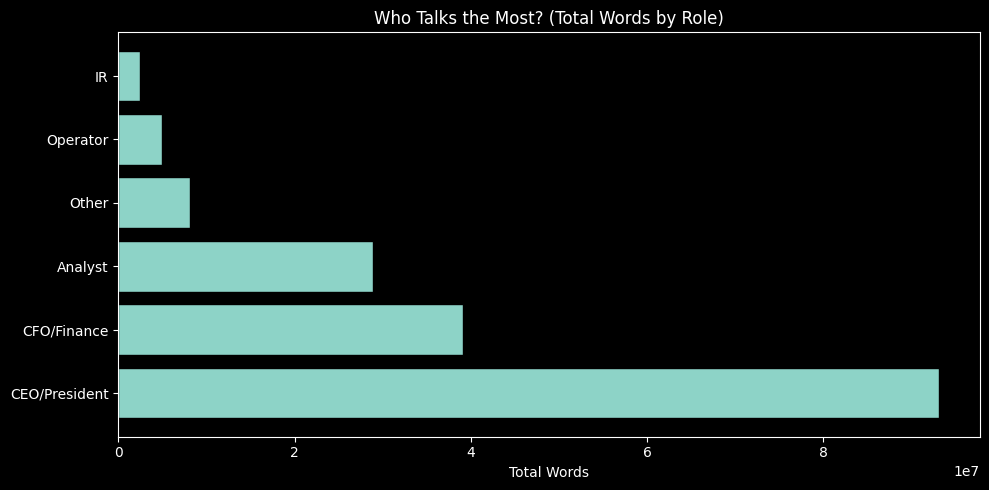

In [33]:
# Speaker role breakdown
speaker_stats = []
for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    for seg in transcript:
        if not isinstance(seg, dict):
            continue
        speaker_stats.append({
            "symbol": row["symbol"],
            "title": seg.get("title", "Unknown"),
            "word_count": len(seg.get("content", "").split()),
        })

speaker_df = pl.DataFrame(speaker_stats)

speaker_df = speaker_df.with_columns(
    pl.when(pl.col("title").str.to_lowercase().str.contains("ceo|chief executive|president"))
      .then(pl.lit("CEO/President"))
    .when(pl.col("title").str.to_lowercase().str.contains("cfo|chief financial|finance"))
      .then(pl.lit("CFO/Finance"))
    .when(pl.col("title").str.to_lowercase().str.contains("analyst|research|managing director"))
      .then(pl.lit("Analyst"))
    .when(pl.col("title").str.to_lowercase().str.contains("operator"))
      .then(pl.lit("Operator"))
    .when(pl.col("title").str.to_lowercase().str.contains("investor relation"))
      .then(pl.lit("IR"))
    .otherwise(pl.lit("Other"))
    .alias("role")
)

role_summary = speaker_df.group_by("role").agg([
    pl.len().alias("segments"),
    pl.col("word_count").sum().alias("total_words"),
    pl.col("word_count").mean().alias("avg_words"),
]).sort("total_words", descending=True)

print("Speaker role breakdown:")
print(role_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(role_summary["role"].to_list(), role_summary["total_words"].to_list(), edgecolor="black")
ax.set_xlabel("Total Words")
ax.set_title("Who Talks the Most? (Total Words by Role)")
plt.tight_layout()
plt.show()

### Prepared Remarks vs Q&A Split

Prepared vs Q&A split:
shape: (9, 4)
┌────────────┬────────────────┬─────────────┬──────────────┐
│ statistic  ┆ prepared_words ┆ qa_words    ┆ prepared_pct │
│ ---        ┆ ---            ┆ ---         ┆ ---          │
│ str        ┆ f64            ┆ f64         ┆ f64          │
╞════════════╪════════════════╪═════════════╪══════════════╡
│ count      ┆ 24132.0        ┆ 24132.0     ┆ 24132.0      │
│ null_count ┆ 0.0            ┆ 0.0         ┆ 0.0          │
│ mean       ┆ 1677.924789    ┆ 5638.343734 ┆ 22.538737    │
│ std        ┆ 1849.540159    ┆ 2683.711322 ┆ 24.300685    │
│ min        ┆ 0.0            ┆ 0.0         ┆ 0.0          │
│ 25%        ┆ 0.0            ┆ 3915.0      ┆ 0.0          │
│ 50%        ┆ 1330.0         ┆ 5616.0      ┆ 19.3         │
│ 75%        ┆ 3087.0         ┆ 7718.0      ┆ 41.3         │
│ max        ┆ 14945.0        ┆ 23546.0     ┆ 100.0        │
└────────────┴────────────────┴─────────────┴──────────────┘


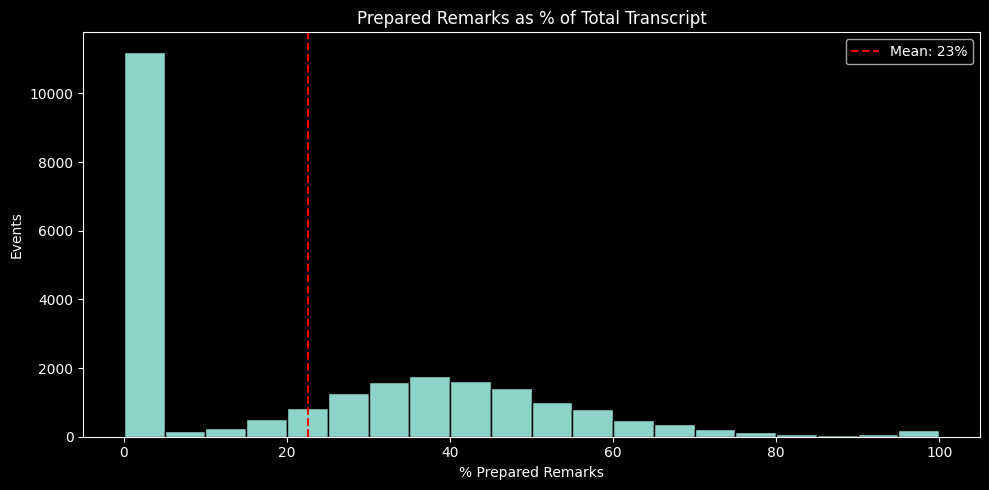

In [34]:
# Detect prepared remarks vs Q&A
def split_sections(transcript):
    if not transcript or len(transcript) == 0:
        return "", "", -1
    
    qa_start = None
    for i, seg in enumerate(transcript):
        if not isinstance(seg, dict):
            continue
        content_lower = seg.get("content", "").lower()
        title_lower = seg.get("title", "").lower()
        if any(m in content_lower for m in [
            "open the call for questions", "open it up for questions",
            "first question", "begin the question", "q&a session",
            "question-and-answer",
        ]):
            qa_start = i
            break
        if i > 3 and "operator" in title_lower and "question" in content_lower:
            qa_start = i
            break
    
    # Fallback: assume Q&A starts at 40% of segments if no marker found
    if qa_start is None:
        qa_start = max(1, int(len(transcript) * 0.4))
    
    prep = " ".join([s.get("content", "") if isinstance(s, dict) else str(s) for s in transcript[:qa_start]])
    qa = " ".join([s.get("content", "") if isinstance(s, dict) else str(s) for s in transcript[qa_start:]])
    return prep, qa, qa_start

section_stats = []
for row in modeling.iter_rows(named=True):
    prep, qa, idx = split_sections(row.get("transcript"))
    total = len(prep.split()) + len(qa.split())
    section_stats.append({
        "symbol": row["symbol"],
        "prepared_words": len(prep.split()),
        "qa_words": len(qa.split()),
        "prepared_pct": round(100 * len(prep.split()) / max(1, total), 1),
    })

sect_df = pl.DataFrame(section_stats)
print("Prepared vs Q&A split:")
print(sect_df.select("prepared_words", "qa_words", "prepared_pct").describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sect_df["prepared_pct"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=sect_df["prepared_pct"].mean(), color="red", linestyle="--",
           label=f"Mean: {sect_df['prepared_pct'].mean():.0f}%")
ax.set_title("Prepared Remarks as % of Total Transcript")
ax.set_xlabel("% Prepared Remarks")
ax.set_ylabel("Events")
ax.legend()
plt.tight_layout()
plt.show()

### Sentence-Level Stats

In [35]:
# Sentence-level analysis
sentence_stats = []

for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript", [])
    text = " ".join([seg.get("content", "") if isinstance(seg, dict) else str(seg) for seg in (transcript or [])])
    if not text.strip():
        continue
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    word_counts = [len(s.split()) for s in sentences]
    token_est = [int(w * 1.3) for w in word_counts]
    
    sentence_stats.append({
        "num_sentences": len(sentences),
        "avg_words": round(np.mean(word_counts), 1),
        "max_words": max(word_counts),
        "over_384_tokens": sum(1 for t in token_est if t > 384),
        "total_tokens": sum(token_est),
    })

sent_df = pl.DataFrame(sentence_stats)
print("Sentence-level statistics:")
print(sent_df.describe())

total_sent = sent_df["num_sentences"].sum()
total_tok = sent_df["total_tokens"].sum()
over = sent_df["over_384_tokens"].sum()

print(f"\n- FinBERT Compute Estimate -")
print(f"Total sentences: {total_sent:,}")
print(f"Total tokens: {total_tok:,}")
print(f"Sentences needing truncation (>384 tokens): {over:,}")
print(f"Estimated batches (batch_size=32): {total_sent // 32 + 1:,}")

Sentence-level statistics:
shape: (9, 6)
┌────────────┬───────────────┬───────────┬───────────┬─────────────────┬──────────────┐
│ statistic  ┆ num_sentences ┆ avg_words ┆ max_words ┆ over_384_tokens ┆ total_tokens │
│ ---        ┆ ---           ┆ ---       ┆ ---       ┆ ---             ┆ ---          │
│ str        ┆ f64           ┆ f64       ┆ f64       ┆ f64             ┆ f64          │
╞════════════╪═══════════════╪═══════════╪═══════════╪═════════════════╪══════════════╡
│ count      ┆ 23012.0       ┆ 23012.0   ┆ 23012.0   ┆ 23012.0         ┆ 23012.0      │
│ null_count ┆ 0.0           ┆ 0.0       ┆ 0.0       ┆ 0.0             ┆ 0.0          │
│ mean       ┆ 436.041152    ┆ 17.736159 ┆ 73.152529 ┆ 0.000739        ┆ 9774.982574  │
│ std        ┆ 107.550092    ┆ 2.127802  ┆ 20.415163 ┆ 0.0302          ┆ 2356.810978  │
│ min        ┆ 21.0          ┆ 8.8       ┆ 26.0      ┆ 0.0             ┆ 346.0        │
│ 25%        ┆ 373.0         ┆ 16.3      ┆ 60.0      ┆ 0.0             ┆ 8434.0

### Boilerplate / Legal Disclaimer Detection


Boilerplate analysis:
  Events analysed:  23,185
  Avg boilerplate:  9.4% of transcript
  Max boilerplate:  97.9%


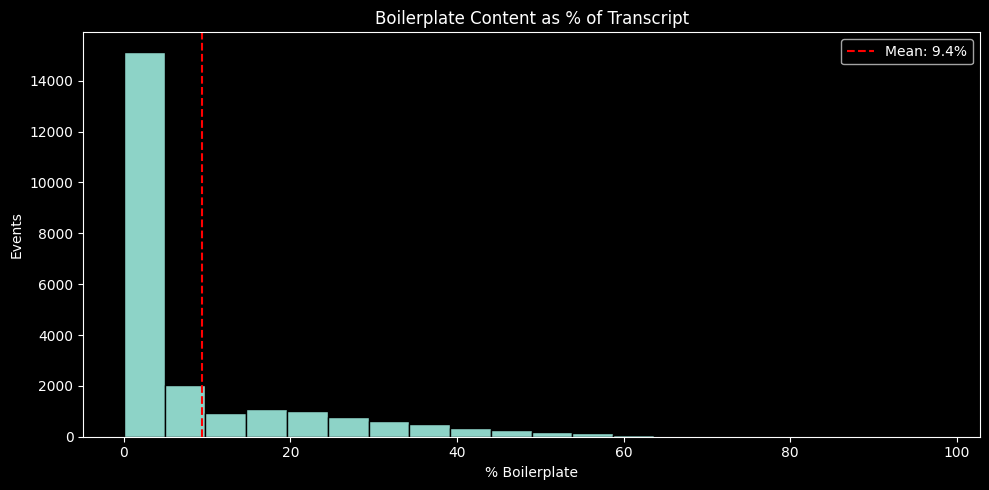

In [37]:
# Boilerplate detection
bp_patterns = [
    "forward-looking statement", "safe harbor", "actual results may differ",
    "risk factors", "non-gaap", "this call is being recorded",
    "all participants are in listen-only", "sec filing", "regulation fd",
]

bp_stats = []
for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    bp_words, total_words = 0, 0
    for seg in transcript:
        text = seg.get("content", "") if isinstance(seg, dict) else str(seg)
        words = len(text.split())
        total_words += words
        if any(p in text.lower() for p in bp_patterns):
            bp_words += words
    bp_stats.append({
        "bp_words": bp_words,
        "total_words": total_words,
        "bp_pct": round(100 * bp_words / max(1, total_words), 1),
    })

bp_df = pl.DataFrame(bp_stats)
print(f"Boilerplate analysis:")
print(f"  Events analysed:  {bp_df.shape[0]:,}")
print(f"  Avg boilerplate:  {bp_df['bp_pct'].mean():.1f}% of transcript")
print(f"  Max boilerplate:  {bp_df['bp_pct'].max():.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bp_df["bp_pct"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=float(bp_df["bp_pct"].mean()), color="red", linestyle="--",
           label=f"Mean: {bp_df['bp_pct'].mean():.1f}%")
ax.set_title("Boilerplate Content as % of Transcript")
ax.set_xlabel("% Boilerplate")
ax.set_ylabel("Events")
ax.legend()
plt.tight_layout()
plt.show()

### Existing Sentiment Field Check


In [38]:
# Check for pre-existing sentiment in transcript data
total_with, total_without = 0, 0
all_sentiments = []

for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    for seg in transcript:
        if not isinstance(seg, dict):
            continue
        sent = seg.get("sentiment")
        if sent and sent != "" and sent != "N/A":
            total_with += 1
            all_sentiments.append(sent)
        else:
            total_without += 1

print(f"Pre-existing sentiment coverage:")
print(f"  With sentiment:    {total_with:,}")
print(f"  Without sentiment: {total_without:,}")
print(f"  Coverage: {100 * total_with / max(1, total_with + total_without):.1f}%")

if total_with > 0:
    dist = pl.Series("sentiment", all_sentiments).value_counts().sort("count", descending=True)
    print(f"\nSentiment distribution:")
    print(dist)
else:
    print("\nNo pre-existing sentiment — FinBERT will compute from scratch")


Pre-existing sentiment coverage:
  With sentiment:    1,525,320
  Without sentiment: 0
  Coverage: 100.0%

Sentiment distribution:
shape: (21, 2)
┌───────────┬────────┐
│ sentiment ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ 0.0       ┆ 641203 │
│ 0.2       ┆ 171025 │
│ 0.5       ┆ 143577 │
│ 0.1       ┆ 128708 │
│ 0.3       ┆ 125731 │
│ …         ┆ …      │
│ -0.6      ┆ 80     │
│ -0.0      ┆ 69     │
│ -0.7      ┆ 17     │
│ -0.8      ┆ 6      │
│ -1.0      ┆ 1      │
└───────────┴────────┘


## Dimensionality Reduction Analysis

PCA input (after dropping inf/NaN rows): (23884, 252)


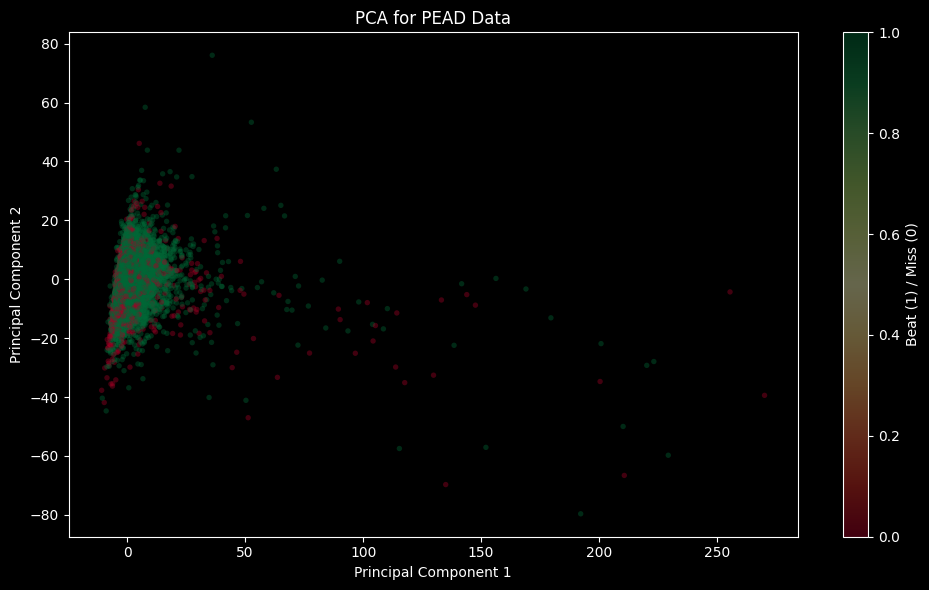

Eigenvalues (first 2): [60.74638903 42.21435217]

Direction of the first two PCs (eigenvectors):
 [[ 2.81696604e-03  1.19479941e-01  1.54782824e-02  2.14168370e-03
   1.25594632e-01  6.17565694e-03  1.25601234e-01  5.76953351e-04
   1.25538181e-01  2.69852573e-02  2.01563184e-02  2.52162089e-02
   1.25526517e-01  1.51972573e-02  1.76339368e-02  2.15709028e-02
   1.62478101e-02  1.84410891e-02 -1.90468149e-03 -7.90157830e-03
   1.81314105e-02  2.86424413e-03  1.19306241e-01  1.62192147e-02
   2.57662851e-03  1.25698804e-01  5.84993117e-03  1.25704850e-01
  -1.26746383e-04  1.25646389e-01  2.89099689e-02  1.92852174e-02
   2.53451019e-02  1.25642035e-01  1.67866269e-02  1.86677021e-02
   2.21740864e-02  1.63930618e-02  1.95356408e-02 -1.62039784e-03
  -7.75951732e-03  1.90318752e-02  2.98569785e-03  1.19300651e-01
   1.74682056e-02  2.88451444e-03  1.25820507e-01  6.10965857e-03
   1.25789430e-01 -4.47171940e-04  1.25739486e-01  3.24594417e-02
   2.28973801e-02  2.54126032e-02  1.2571384

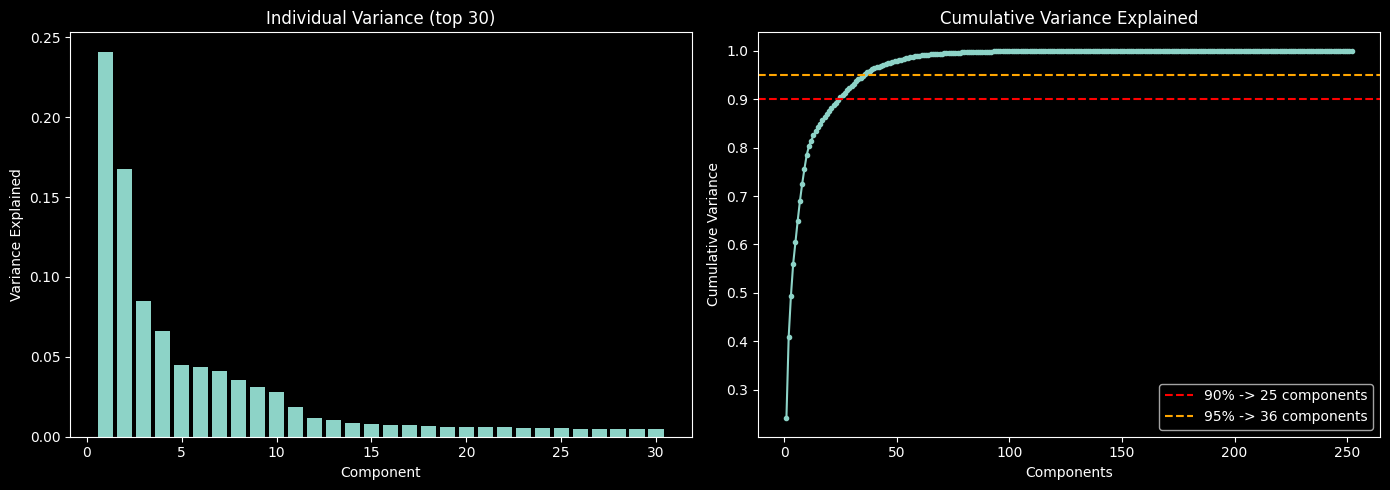

Original features:       252
Components for 90% var:  25  (90% reduction)
Components for 95% var:  36  (86% reduction)


In [39]:
# PCA on pivoted columns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare data — replace inf with NaN, drop incomplete rows
pca_data = modeling.select(pivoted_cols).to_pandas()
pca_data = pca_data.replace([np.inf, -np.inf], np.nan).dropna()
print(f"PCA input (after dropping inf/NaN rows): {pca_data.shape}")

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Perform PCA (map 216-dimensional space to 2D for visualization)
pca = PCA(n_components=2)
pca.fit(scaled_data)
transformed_data = pca.transform(scaled_data)

# Get beat/miss labels aligned to the cleaned rows
labels = modeling.select("beat").to_pandas().loc[pca_data.index, "beat"].values

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1],
            c=labels, cmap="RdYlGn", alpha=0.4, s=15, edgecolors="none")
plt.colorbar(label="Beat (1) / Miss (0)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA for PEAD Data")
plt.tight_layout()
plt.show()

# PCA outputs
eigen_values = pca.explained_variance_
eigen_vectors = pca.components_
variance = pca.explained_variance_ratio_

print("Eigenvalues (first 2):", eigen_values)
print("\nDirection of the first two PCs (eigenvectors):\n", eigen_vectors)
print("\nVariance ratio for the first two PCs:", variance)
print("\nTotal variance captured:", round(variance.sum(), 4))

# retain components
pca_full = PCA()
pca_full.fit(scaled_data)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_) + 1)),
            pca_full.explained_variance_ratio_[:30])
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance Explained")
axes[0].set_title("Individual Variance (top 30)")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker=".")
axes[1].axhline(y=0.90, color="red", linestyle="--", label=f"90% -> {n_90} components")
axes[1].axhline(y=0.95, color="orange", linestyle="--", label=f"95% -> {n_95} components")
axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Original features:       {len(pivoted_cols)}")
print(f"Components for 90% var:  {n_90}  ({100*(1 - n_90/len(pivoted_cols)):.0f}% reduction)")
print(f"Components for 95% var:  {n_95}  ({100*(1 - n_95/len(pivoted_cols)):.0f}% reduction)")

23 components capturing 90% of variance represents an 89% dimensionality reduction
from 216 pivoted features. However, PCA components are not interpretable, which
conflicts with the goal of understanding which features drive drift. The plan for
Milestone 4 is to use **correlation filtering first** (removing redundant raw price
columns) to get to ~75 features, then apply PCA only if needed for the DNN. Tree
models (XGBoost, Random Forest) will use the filtered feature set directly since
they handle correlated features natively.

In [40]:
# Correlation-based feature selection
corr_abs = pca_data.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Correlation-based selection (threshold=0.95):")
print(f"  Highly correlated: {len(high_corr)}")
print(f"  Remaining: {len(pivoted_cols) - len(high_corr)}")
print(f"\nComparison:")
print(f"  Original:          {len(pivoted_cols)}")
print(f"  After PCA (90%):   {n_90}")
print(f"  After corr filter: {len(pivoted_cols) - len(high_corr)}")


Correlation-based selection (threshold=0.95):
  Highly correlated: 146
  Remaining: 106

Comparison:
  Original:          252
  After PCA (90%):   25
  After corr filter: 106


In [41]:
# Preprocessing readiness summary
print("Preprocessing Readiness Checklist")
print("-" * 55)

n_events = modeling.shape[0]
total_nulls = modeling.null_count().sum_horizontal()[0]
null_pct = 100 * total_nulls / (n_events * modeling.shape[1])

# Inf counts in pivoted columns
inf_count = 0
for c in pivoted_cols:
    inf_count += modeling.select(pl.col(c).is_infinite().sum())[0, 0]

print(f"Events:              {n_events:,}")
print(f"Features:            {modeling.shape[1]}")
print(f"Total nulls:         {total_nulls:,} ({null_pct:.2f}%)")
print(f"Total infs (pivoted):{inf_count:,}")
print(f"Beat/miss ratio:     {modeling['beat'].mean():.1%} / {1 - modeling['beat'].mean():.1%}")
print(f"Low-event stocks:    {modeling.group_by('symbol').len().filter(pl.col('len') < 10).shape[0]}")
print(f"PCA target:          {len(pivoted_cols)} pivoted -> ~{n_90} components (90% var)")

Preprocessing Readiness Checklist
-------------------------------------------------------
Events:              24,132
Features:            275
Total nulls:         2,143 (0.03%)
Total infs (pivoted):91
Beat/miss ratio:     73.3% / 26.7%
Low-event stocks:    4
PCA target:          252 pivoted -> ~25 components (90% var)


## Preprocessing Plan

Summary of decisions for Milestone 4 based on EDA findings above.

In [42]:
## Preprocessing strategy per column type

preprocessing_plan = [
    # (Column group, Issue found, Strategy)
    ("sma200_* pivoted cols",    "Nulls for early 2014 events (~200 day warmup)", "Median impute per symbol"),
    ("eps_growth",               "Null for first event per symbol",               "Fill with 0 (no prior quarter)"),
    ("target_return",            "Null for events near end of history",            "Drop row from training set"),
    ("sector / industry",        "~handful of null symbols from yfinance",         "Fill with 'Unknown' category"),
    ("inf values (pivoted)",     "91 inf values from division by zero",            "Replace with NaN, then impute"),
    ("close / volume (pivoted)", "Absolute dollar terms, not cross-stock comparable", "Normalize by close_t-10"),
    ("All TA features",          "Different scales (RSI 0-100, ATR in $, etc.)",  "StandardScaler before PCA / DNN"),
    ("beat (target)",            "73.3% beat rate — class imbalance",             "class_weight='balanced' or SMOTE"),
    ("transcript text",          "~3,822 missing; boilerplate ~9.2%",             "Strip boilerplate, FinBERT on remainder"),
]

print(f"{'Column Group':<35} {'Issue':<48} {'Strategy'}")
print("-" * 120)
for col, issue, strategy in preprocessing_plan:
    print(f"{col:<35} {issue:<48} {strategy}")

Column Group                        Issue                                            Strategy
------------------------------------------------------------------------------------------------------------------------
sma200_* pivoted cols               Nulls for early 2014 events (~200 day warmup)    Median impute per symbol
eps_growth                          Null for first event per symbol                  Fill with 0 (no prior quarter)
target_return                       Null for events near end of history              Drop row from training set
sector / industry                   ~handful of null symbols from yfinance           Fill with 'Unknown' category
inf values (pivoted)                91 inf values from division by zero              Replace with NaN, then impute
close / volume (pivoted)            Absolute dollar terms, not cross-stock comparable Normalize by close_t-10
All TA features                     Different scales (RSI 0-100, ATR in $, etc.)     StandardScaler before P